# Feature Extraction and Price Prediction for Mobile Phones

**Role:** Senior Data Scientist & Machine Learning Engineer  
**Use cases:** Internship portfolio • GitHub • HR evaluation • Technical interview • Product/company ML discussion

## Executive Summary

This notebook builds an explainable end-to-end machine-learning system for smartphone price prediction. It first audits the supplied specification data, then converts raw specification fields into usable numerical and categorical features, compares multiple regression models, validates them with 5-fold cross-validation, tunes the strongest candidate, and explains the final model with feature importance and permutation importance.

**Important methodology rule:** specification formats are inspected before parsing. The notebook does not assume units merely because a column name suggests them. Any interpretation is explicitly documented from the observed values.

## 1. Project Introduction

The supplied project brief asks for a predictive model that estimates mobile-phone prices and identifies the features most strongly associated with price. It also calls for preprocessing, feature extraction, model evaluation, feature-importance analysis, visualizations, and business recommendations.

The notebook follows that intent while adding a stronger ML workflow: reproducible train/test splitting, leakage-safe preprocessing, feature-engineering ablation, cross-validation, hyperparameter tuning, and model explainability.

## 2. Business Problem

A mobile-phone seller needs to understand how hardware and product specifications relate to market price. Raw specifications are often stored as mixed text, categorical values, and inconsistent formats, which makes direct modeling difficult.

The business problem is therefore twofold:

1. Predict a reasonable price for a phone from its available specifications.
2. Identify which specifications and derived attributes provide the strongest predictive signal.

## 3. Business Objective

Build a model that can support:

- price estimation for new or existing phone configurations,
- product-positioning analysis,
- identification of high-value specifications,
- pricing and marketing decisions,
- discussion of model trade-offs in a technical interview.

The model is **decision support**, not a causal pricing engine. Feature importance indicates predictive association, not proof that changing a specification will cause a specific price increase.

## 4. Dataset Description

The expected business fields are:

`Sr.no`, `Model`, `Colour`, `Memory`, `RAM`, `Battery_`, `Rear Camera`, `Front Camera`, `AI Lens`, `Mobile Height`, `Processor_`, and `Price`.

The supplied CSV is slightly different: it contains `Unnamed: 0` instead of `Sr.no`, and the target is named `Prize` instead of `Price`. The notebook detects and standardizes those names rather than silently assuming the documented names are exact.

The supplied file contains **541 rows and 12 columns** before cleaning.

## 5. Import Libraries

The notebook uses pandas/NumPy for data work, Matplotlib/Seaborn for visualization, SciPy for statistical support, and scikit-learn for preprocessing, feature selection, regression, validation, tuning, and explainability.

In [36]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid", context="notebook")
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 6. Load Dataset

For GitHub use, keep `mobile_phone.csv` in the same folder as this notebook. Change `DATA_PATH` only when the file is stored elsewhere.

In [37]:
DATA_PATH = Path("C:\\Users\\sarth\\OneDrive\\Documents\\Digicrome\\Intership 12 Month\\Project 4\\mobile_phone.csv")
    

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}. "
        "Place mobile_phone.csv beside the notebook or update DATA_PATH."
    )

raw_df = pd.read_csv(DATA_PATH)

print(f"Shape: {raw_df.shape}")
display(raw_df.head())


Shape: (541, 12)


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


## 7. Data Understanding

Before transforming anything, inspect:

- column names,
- data types,
- number of unique values,
- representative unique values,
- missingness,
- target format.

This step is intentionally placed before specification parsing so the extraction logic is based on the actual dataset.

In [38]:
print("Column names:")
print(raw_df.columns.tolist())


Column names:
['Unnamed: 0', 'Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize']


In [39]:
print("\nData types:")
display(raw_df.dtypes.to_frame("dtype"))


Data types:


,dtype
Unnamed: 0,int64
Model,str
Colour,str
Memory,int64
RAM,int64
Battery_,int64
Rear Camera,str
Front Camera,str
AI Lens,int64
Mobile Height,float64


In [40]:
raw_df = raw_df.drop(columns=['Unnamed: 0'], errors='ignore')
print("\nBasic shape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())
display(raw_df.head(5))


Basic shape: (541, 11)
Columns: ['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize']


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [41]:
raw_df.rename(columns={
    'Battery_': 'Battery_Level',
    'Processor': 'Processor_Type'
}, inplace=True)

raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    str    
 1   Colour         541 non-null    str    
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_Level  541 non-null    int64  
 5   Rear Camera    541 non-null    str    
 6   Front Camera   541 non-null    str    
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    str    
 10  Prize          541 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 46.6 KB


In [42]:
print("-" * 50)
print("Columns                 null values")
print("-" * 50)
for column in raw_df.columns:
    print(f"{column:<24}: {raw_df[column].isnull().sum()}")

--------------------------------------------------
Columns                 null values
--------------------------------------------------
Model                   : 0
Colour                  : 0
Memory                  : 0
RAM                     : 0
Battery_Level           : 0
Rear Camera             : 0
Front Camera            : 0
AI Lens                 : 0
Mobile Height           : 0
Processor_              : 0
Prize                   : 0


### Specification-format audit

The supplied dataset shows:

- `Memory`: integer values such as 16, 32, 64, 128, 256.
- `RAM`: integer values such as 2, 3, 4, 6, 8.
- `Battery_`: integer values ranging from 800 to 7000.
- `Rear Camera` / `Front Camera`: strings such as `13MP`, `50MP`, `108MP`, `0MP`.
- `AI Lens`: binary 0/1.
- `Mobile Height`: numeric values, but the distribution contains suspicious values such as 4.50, 6.10, 7.11 and 41.94 alongside the dominant ~15–18 range.
- `Processor_`: free text with many naming variants.
- `Prize`: comma-formatted price strings such as `7,299`, `49,999`, etc.

The notebook therefore parses only fields for which the observed representation supports a defensible extraction.

In [43]:
SPEC_COLUMNS = [
    "Model", "Colour", "Memory", "RAM", "Battery_",
    "Rear Camera", "Front Camera", "AI Lens",
    "Mobile Height", "Processor_"
]

for col in SPEC_COLUMNS:
    if col not in raw_df.columns:
        print(f"WARNING: expected specification column missing: {col}")
        continue

    values = raw_df[col].dropna().astype(str).unique()
    print(f"\n--- {col} ---")
    print(f"dtype={raw_df[col].dtype} | unique={raw_df[col].nunique(dropna=False)}")
    print(values[:30])
    if len(values) > 30:
        print(f"... {len(values) - 30} more unique values")



--- Model ---
dtype=str | unique=187
<StringArray>
[      'Infinix SMART 7',          'MOTOROLA G32',              'POCO C50',
       'Infinix HOT 30i',              'REDMI 10',    'SAMSUNG Galaxy F13',
    'SAMSUNG Galaxy F04',              'POCO C51',          'MOTOROLA e13',
           'vivo T2x 5G',    'Infinix Smart 7 HD',             'REDMI A1+',
              'POCO C55',          'MOTOROLA g13',            'POCO M4 5G',
          'MOTOROLA e32',            'vivo T2 5G',       'MOTOROLA G62 5G',
               'POCO M5',       'realme C33 2023', 'SAMSUNG Galaxy F14 5G',
       'MOTOROLA g73 5G',            'realme C30',            'POCO X5 5G',
           'POCO M4 Pro',        'REDMI 11 Prime',            'realme C55',
      'realme 10 Pro 5G',        'Micromax IN 2C',        'POCO M4 Pro 5G']
Length: 30, dtype: str
... 157 more unique values

--- Colour ---
dtype=str | unique=275
<StringArray>
[    'Night Black',      'Azure Blue',    'Mineral Gray',      'Royal Blue',
        

## 8. Data Quality Analysis

The quality audit checks:

- missing values,
- blank strings,
- duplicate records,
- inconsistent target naming,
- impossible/non-numeric target values,
- suspicious numeric ranges.

No row is deleted simply because it is an expensive phone. Premium phones are legitimate observations and can be important to the pricing problem.

In [44]:
quality = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing": raw_df.isna().sum(),
    "missing_pct": (raw_df.isna().mean() * 100).round(2),
    "unique": raw_df.nunique(dropna=False)
}).sort_values(["missing", "unique"], ascending=[False, True])

display(quality)

blank_counts = {}
for col in raw_df.select_dtypes(include="object").columns:
    blank_counts[col] = raw_df[col].astype(str).str.strip().eq("").sum()

print("Blank-string counts:")
display(pd.Series(blank_counts, name="blank_strings").to_frame())


,dtype,missing,missing_pct,unique
AI Lens,int64,0,0.0,2
Memory,int64,0,0.0,5
RAM,int64,0,0.0,5
Front Camera,str,0,0.0,13
Rear Camera,str,0,0.0,14
Battery_Level,int64,0,0.0,37
Mobile Height,float64,0,0.0,38
Processor_,str,0,0.0,123
Prize,str,0,0.0,158
Model,str,0,0.0,187


Blank-string counts:


,blank_strings
Model,0
Colour,0
Rear Camera,0
Front Camera,0
Processor_,0
Prize,0


In [45]:
import pandas as pd

# Convert columns to numeric
df_outlier = raw_df.copy()

for col in ['Memory', 'RAM', 'Battery_Level', 'Rear Camera',
            'Front Camera', 'AI Lens', 'Mobile Height', 'Prize']:
    df_outlier[col] = pd.to_numeric(
        df_outlier[col].astype(str).str.extract(r'(\d+\.?\d*)')[0],
        errors='coerce'
    )

# Calculate outliers using IQR
outlier_counts = []

for col in ['Memory', 'RAM', 'Battery_Level', 'Rear Camera',
            'Front Camera', 'AI Lens', 'Mobile Height', 'Prize']:

    Q1 = df_outlier[col].quantile(0.25)
    Q3 = df_outlier[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df_outlier[col] < lower_bound) |
        (df_outlier[col] > upper_bound)
    ).sum()

    outlier_counts.append([col, outlier_count])

# Create output table
outlier_df = pd.DataFrame(
    outlier_counts,
    columns=['Feature', 'Outlier Count']
)

display(outlier_df)

,Feature,Outlier Count
0,Memory,55
1,RAM,0
2,Battery_Level,152
3,Rear Camera,39
4,Front Camera,13
5,AI Lens,34
6,Mobile Height,33
7,Prize,24


## 9. Missing Value Analysis

Missing values are not imputed globally before splitting. The final ML workflow performs numerical and categorical imputation **inside the Pipeline**, so statistics are learned only from the training folds.

In [46]:
missing_report = (
    raw_df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: (x["missing_count"] / len(raw_df) * 100).round(2))
    .sort_values("missing_count", ascending=False)
)

display(missing_report)

if missing_report["missing_count"].sum() == 0:
    print("No explicit NaN values are present in the supplied CSV.")
else:
    print("Missing values detected; final preprocessing will handle them inside the ML pipeline.")


,missing_count,missing_pct
Model,0,0.0
Colour,0,0.0
Memory,0,0.0
RAM,0,0.0
Battery_Level,0,0.0
Rear Camera,0,0.0
Front Camera,0,0.0
AI Lens,0,0.0
Mobile Height,0,0.0
Processor_,0,0.0


No explicit NaN values are present in the supplied CSV.


In [47]:
num_cols = raw_df.select_dtypes('number').columns

result = pd.DataFrame({
    'Feature': num_cols,
    'Skewness': [round(raw_df[c].skew(), 2) for c in num_cols],
    'Skewness Type': ['Highly Right-Skewed' if raw_df[c].skew() > 1 else
                      'Highly Left-Skewed' if raw_df[c].skew() < -1 else
                      'Approximately Symmetric' for c in num_cols],
    'Kurtosis': [round(raw_df[c].kurt(), 2) for c in num_cols],
    'Kurtosis Type': ['Leptokurtic' if raw_df[c].kurt() > 0 else
                      'Platykurtic' for c in num_cols]
})

display(result)

,Feature,Skewness,Skewness Type,Kurtosis,Kurtosis Type
0,Memory,1.03,Highly Right-Skewed,0.86,Leptokurtic
1,RAM,0.07,Approximately Symmetric,-1.31,Platykurtic
2,Battery_Level,-3.30,Highly Left-Skewed,14.75,Leptokurtic
3,AI Lens,3.61,Highly Right-Skewed,11.09,Leptokurtic
4,Mobile Height,1.17,Highly Right-Skewed,48.22,Leptokurtic


## 10. Duplicate Analysis

Two duplicate checks are useful:

1. Exact duplicate rows, including the index-like column.
2. Duplicate records after excluding the index-like column.

The second check is more meaningful here because `Unnamed: 0` is an identifier and should not define whether two product records are duplicates.

In [48]:
duplicate_full = raw_df.duplicated().sum()

index_like = [c for c in raw_df.columns if c.strip().lower() in {"unnamed: 0", "sr.no", "sr_no"}]
duplicate_without_id = raw_df.drop(columns=index_like, errors="ignore").duplicated().sum()

print(f"Exact duplicate rows: {duplicate_full}")
print(f"Duplicate product records after excluding index-like column(s): {duplicate_without_id}")

if duplicate_without_id:
    dup_view = raw_df.drop(columns=index_like, errors="ignore")
    display(dup_view[dup_view.duplicated(keep=False)].sort_values(list(dup_view.columns)).head(30))
    print("Identical records are removed later because they duplicate the same feature/target combination.")


Exact duplicate rows: 10
Duplicate product records after excluding index-like column(s): 10


,Model,Colour,Memory,RAM,Battery_Level,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
46,MOTOROLA e32,Arctic Blue,64,4,5000,50MP,8MP,0,16.51,Mediatek Helio G37,"7,999"
48,MOTOROLA e32,Arctic Blue,64,4,5000,50MP,8MP,0,16.51,Mediatek Helio G37,"7,999"
479,POCO C31,Royal Blue,64,4,5000,13MP,5MP,0,16.59,MediaTek G35,"8,999"
480,POCO C31,Royal Blue,64,4,5000,13MP,5MP,0,16.59,MediaTek G35,"8,999"
350,POCO X4 Pro 5G,Laser Black,128,8,5000,64MP,16MP,0,16.94,Qualcomm Snapdragon 695 5G,"19,499"
352,POCO X4 Pro 5G,Laser Black,128,8,5000,64MP,16MP,0,16.94,Qualcomm Snapdragon 695 5G,"19,499"
90,SAMSUNG Galaxy F14 5G,B.A.E. Purple,128,4,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core","13,490"
91,SAMSUNG Galaxy F14 5G,B.A.E. Purple,128,4,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core","13,490"
130,SAMSUNG Galaxy F14 5G,OMG Black,128,6,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core","14,490"
132,SAMSUNG Galaxy F14 5G,OMG Black,128,6,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core","14,490"


Identical records are removed later because they duplicate the same feature/target combination.


## 11. Outlier Analysis

Outlier detection is diagnostic, not an automatic deletion rule.

For price, an unusually high value may represent a legitimate premium smartphone. For `Mobile Height`, the data contains values that look inconsistent with the dominant distribution; these are flagged for review rather than silently deleted.

This preserves business observations while making data-quality concerns visible.

In [49]:
# Standardize target name temporarily for the audit
audit_df = raw_df.copy()
if "Prize" in audit_df.columns and "Price" not in audit_df.columns:
    audit_df = audit_df.rename(columns={"Prize": "Price"})

if "Price" in audit_df.columns:
    audit_df["Price_numeric"] = pd.to_numeric(
        audit_df["Price"].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

def iqr_outlier_report(data, columns):
    rows = []
    for col in columns:
        s = pd.to_numeric(data[col], errors="coerce").dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((s < lower) | (s > upper)).sum()
        rows.append([col, q1, q3, lower, upper, int(count)])
    return pd.DataFrame(
        rows,
        columns=["feature", "Q1", "Q3", "lower_bound", "upper_bound", "outlier_count"]
    )

numeric_candidates = [
    c for c in ["Memory", "RAM", "Battery_", "AI Lens", "Mobile Height", "Price_numeric"]
    if c in audit_df.columns
]

outlier_report = iqr_outlier_report(audit_df, numeric_candidates)
display(outlier_report)

if "Mobile Height" in audit_df.columns:
    q1, q3 = audit_df["Mobile Height"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    height_flags = audit_df[(audit_df["Mobile Height"] < lo) | (audit_df["Mobile Height"] > hi)]
    print(f"Mobile Height IQR flags: {len(height_flags)} rows")
    display(height_flags[["Model", "Mobile Height", "Price"]].head(20))


,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,Memory,64.00,128.00,-32.000,224.000,55
1,RAM,4.00,8.00,-2.000,14.000,0
2,AI Lens,0.00,0.00,0.000,0.000,34
3,Mobile Height,16.51,16.94,15.865,17.585,33
4,Price_numeric,9290.00,19280.00,-5695.000,34265.000,25


Mobile Height IQR flags: 33 rows


,Model,Mobile Height,Price
75,MOTOROLA G62 5G,41.94,"16,499"
88,MOTOROLA G62 5G,41.94,"16,499"
98,Micromax IN 2C,4.50,"1,449"
108,micromax 2,7.11,"1,849"
116,micromax,4.50,"1,422"
118,micromax 1,4.50,"1,299"
133,Micromax 3,6.10,"2,615"
135,Google Pixel 6a,15.60,"28,999"
136,Google Pixel 6a,15.60,"28,999"
152,micromax 3,5.08,"2,490"


## 12. Data Cleaning

Cleaning decisions:

- Rename `Prize` → `Price` because it is the target field.
- Rename `Unnamed: 0` → `Sr.no` when present.
- Convert price strings such as `7,299` to numeric.
- Normalize obvious whitespace.
- Remove exact duplicate product records after excluding the index-like column.
- Keep legitimate price extremes.
- Replace infinite engineered values with `NaN`; imputation happens later inside the pipeline.

No global mean/median imputation is performed here.

In [50]:
df = raw_df.copy()

# Standardize column names used by this notebook
if "Prize" in df.columns and "Price" not in df.columns:
    df = df.rename(columns={"Prize": "Price"})

if "Unnamed: 0" in df.columns and "Sr.no" not in df.columns:
    df = df.rename(columns={"Unnamed: 0": "Sr.no"})

# Normalize text fields
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("string").str.strip()
    df[col] = df[col].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

# Parse target
df["Price"] = pd.to_numeric(
    df["Price"].astype("string").str.replace(",", "", regex=False),
    errors="coerce"
)

# Drop rows with no target
df = df.dropna(subset=["Price"]).copy()

# Remove duplicate product records, ignoring the identifier column
dedup_cols = [c for c in df.columns if c != "Sr.no"]
before = len(df)
df = df.drop_duplicates(subset=dedup_cols, keep="first").reset_index(drop=True)

print(f"Rows before duplicate removal: {before}")
print(f"Rows after duplicate removal:  {len(df)}")
print(f"Duplicate product records removed: {before - len(df)}")
display(df.head())


Rows before duplicate removal: 541
Rows after duplicate removal:  531
Duplicate product records removed: 10


,Model,Colour,Memory,RAM,Battery_Level,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Price
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


## 13. Specification Parsing

The parser is deliberately simple and auditable.

### Supported interpretations from the observed data

- `Memory` values are discrete storage-like values: 16, 32, 64, 128, 256.
- `RAM` values are memory-like values: 2, 3, 4, 6, 8.
- Camera fields explicitly contain the `MP` suffix, so the numeric megapixel value can be extracted.
- `Battery_` contains values in a smartphone-battery range, so it is retained as a numeric battery-capacity feature and documented as **mAh-style data based on the observed values**, not as a blindly assumed unit label.
- `Mobile Height` is retained as supplied; suspicious values are not forcibly converted or deleted because the source does not provide a reliable unit specification.

The notebook keeps the raw fields alongside the engineered representations so the transformation remains traceable.

In [51]:
def parse_numeric(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"[-+]?\d*\.?\d+", str(value).replace(",", ""))
    return float(match.group()) if match else np.nan

def parse_mp(series):
    return series.astype("string").str.extract(
        r"(\d+\.?\d*)", expand=False
    ).astype(float)

print("Observed Memory values:", sorted(pd.to_numeric(raw_df["Memory"], errors="coerce").dropna().unique().tolist()))
print("Observed RAM values:", sorted(pd.to_numeric(raw_df["RAM"], errors="coerce").dropna().unique().tolist()))
print("Observed Battery values:", sorted(pd.to_numeric(raw_df["Battery_Level"], errors="coerce").dropna().unique().tolist()))
print("Observed Rear Camera values:", raw_df["Rear Camera"].dropna().unique().tolist())
print("Observed Front Camera values:", raw_df["Front Camera"].dropna().unique().tolist())

Observed Memory values: [16, 32, 64, 128, 256]
Observed RAM values: [2, 3, 4, 6, 8]
Observed Battery values: [800, 1000, 1020, 1200, 1500, 1900, 2550, 2815, 3000, 3100, 3110, 3300, 3900, 4000, 4020, 4030, 4050, 4115, 4200, 4270, 4300, 4323, 4400, 4410, 4500, 4600, 4610, 4700, 4800, 4830, 4980, 5000, 5020, 5080, 5200, 6000, 7000]
Observed Rear Camera values: ['13MP', '50MP', '8MP', '40MP', '32MP', '48MP', '64MP', '108MP', '0MP', '2MP', '12MP', '200MP', '5MP', '16MP']
Observed Front Camera values: ['5MP', '16MP', '8MP', '13MP', '0MP', '32MP', '10MP', '50MP', '60MP', '20MP', '44MP', '2MP', '12MP']


## 14. Feature Engineering

At least 15 derived features are required. This notebook creates **20 engineered features** where the source data supports them.

### Engineered features

1. `ram_gb`
2. `storage_gb`
3. `battery_mah`
4. `rear_camera_mp`
5. `front_camera_mp`
6. `camera_total_mp`
7. `camera_ratio`
8. `ram_storage_ratio`
9. `battery_per_ram`
10. `storage_per_ram`
11. `battery_per_storage`
12. `premium_hardware_score`
13. `camera_score`
14. `memory_tier`
15. `ram_tier`
16. `battery_tier`
17. `camera_tier`
18. `ai_feature_flag`
19. `brand_from_model`
20. `processor_family`

### Ratio safety

All ratio denominators are protected with `replace(0, NaN)`. After feature creation, positive/negative infinity is replaced with `NaN`. Missing values are then handled inside the ML pipeline.

### Composite-score design

`premium_hardware_score` is a **heuristic predictive feature**, not a causal scientific score. It averages normalized components:

`score = mean(ram_norm, storage_norm, battery_norm, camera_norm, ai_flag)`

Reference scales are fixed from the observed specification ranges: RAM 8 GB, storage 256 GB, battery 7000, total camera 260 MP. Components are clipped to [0, 1].

`camera_score` is:

`0.70 × normalized rear camera + 0.30 × normalized front camera`

The weights are a modeling heuristic, not a claim that rear camera capability is causally 70% of camera value.

In [52]:
import pandas as pd
import numpy as np
import re

raw_df.columns = raw_df.columns.str.strip()
raw_df.drop(columns="Unnamed: 0", errors="ignore", inplace=True)
raw_df.rename(columns={"Battery_":"Battery_Level","Processor_":"Processor_Type","Processor":"Processor_Type"}, inplace=True)

def parse_mp(s):
    return s.astype("string").str.extract(r"(\d+\.?\d*)", expand=False).astype(float)

def normalize_text(s):
    return s.astype("string").str.strip().str.lower().str.replace(r"\s+"," ",regex=True)

def extract_brand(s):
    s = normalize_text(s)
    return pd.Series(np.where(s.str.startswith("i kall"),"i kall",
                     np.where(s.str.startswith("micromax"),"micromax",s.str.split().str[0])),
                     index=s.index,dtype="string")

def processor_family(t):
    t = str(t).lower()
    if "snapdragon" in t: return "Qualcomm Snapdragon"
    if any(k in t for k in ["dimensity","mediatek","helio","mtk"]): return "MediaTek"
    if "exynos" in t: return "Samsung Exynos"
    if "tensor" in t: return "Google Tensor"
    if any(k in t for k in ["unisoc","spreadtrum","tiger"]) or re.search(r"\bsc\d+",t): return "UNISOC/Spreadtrum"
    if "apple" in t: return "Apple"
    if any(k in t for k in ["octa","quad core","6 core"]): return "Generic Core Descriptor"
    return "Other/Unspecified"

def build_engineered_features(d):
    x = d.copy()
    x["ram_gb"] = pd.to_numeric(x["RAM"],errors="coerce")
    x["storage_gb"] = pd.to_numeric(x["Memory"],errors="coerce")
    x["battery_mah"] = pd.to_numeric(x["Battery_Level"],errors="coerce")
    x["rear_camera_mp"] = parse_mp(x["Rear Camera"])
    x["front_camera_mp"] = parse_mp(x["Front Camera"])
    x["camera_total_mp"] = x["rear_camera_mp"] + x["front_camera_mp"]

    x["camera_ratio"] = x["rear_camera_mp"]/x["front_camera_mp"].replace(0,np.nan)
    x["ram_storage_ratio"] = x["ram_gb"]/x["storage_gb"].replace(0,np.nan)
    x["battery_per_ram"] = x["battery_mah"]/x["ram_gb"].replace(0,np.nan)
    x["storage_per_ram"] = x["storage_gb"]/x["ram_gb"].replace(0,np.nan)
    x["battery_per_storage"] = x["battery_mah"]/x["storage_gb"].replace(0,np.nan)

    x["ai_feature_flag"] = pd.to_numeric(x["AI Lens"],errors="coerce")
    x["brand_from_model"] = extract_brand(x["Model"])
    x["processor_family"] = x["Processor_Type"].map(processor_family)

    x["memory_tier"] = pd.cut(x["storage_gb"],[-np.inf,32,64,128,np.inf],labels=["Entry","Standard","High","Ultra"])
    x["ram_tier"] = pd.cut(x["ram_gb"],[-np.inf,2,4,6,np.inf],labels=["Entry","Standard","High","Ultra"])
    x["battery_tier"] = pd.cut(x["battery_mah"],[-np.inf,3000,4500,5500,np.inf],labels=["Low","Standard","High","Very High"])
    x["camera_tier"] = pd.cut(x["camera_total_mp"],[-np.inf,8,20,60,120,np.inf],labels=["Basic","Standard","Advanced","High","Ultra"])

    score = [
        np.clip(x["ram_gb"]/8,0,1),
        np.clip(np.log2(x["storage_gb"].clip(lower=1))/8,0,1),
        np.clip(x["battery_mah"]/7000,0,1),
        np.clip(x["camera_total_mp"]/260,0,1),
        x["ai_feature_flag"].clip(0,1)
    ]
    x["premium_hardware_score"] = pd.concat(score,axis=1).mean(axis=1)
    x["camera_score"] = .70*np.clip(x["rear_camera_mp"]/200,0,1)+.30*np.clip(x["front_camera_mp"]/60,0,1)

    return x.replace([np.inf,-np.inf],np.nan)

df_fe = build_engineered_features(raw_df)

ENGINEERED_FEATURES = [
    "ram_gb","storage_gb","battery_mah","rear_camera_mp","front_camera_mp",
    "camera_total_mp","camera_ratio","ram_storage_ratio","battery_per_ram",
    "storage_per_ram","battery_per_storage","premium_hardware_score",
    "camera_score","memory_tier","ram_tier","battery_tier","camera_tier",
    "ai_feature_flag","brand_from_model","processor_family"
]

print(f"Engineered feature count: {len(ENGINEERED_FEATURES)}")
display(df_fe[ENGINEERED_FEATURES].head())

Engineered feature count: 20


,ram_gb,storage_gb,battery_mah,rear_camera_mp,front_camera_mp,camera_total_mp,camera_ratio,ram_storage_ratio,battery_per_ram,storage_per_ram,battery_per_storage,premium_hardware_score,camera_score,memory_tier,ram_tier,battery_tier,camera_tier,ai_feature_flag,brand_from_model,processor_family
0,4,64,6000,13.0,5.0,18.0,2.600,0.0625,1500.0,16.0,93.7500,0.635275,0.0705,Standard,Standard,Very High,Standard,1,infinix,UNISOC/Spreadtrum
1,4,64,6000,13.0,5.0,18.0,2.600,0.0625,1500.0,16.0,93.7500,0.635275,0.0705,Standard,Standard,Very High,Standard,1,infinix,UNISOC/Spreadtrum
2,8,128,5000,50.0,16.0,66.0,3.125,0.0625,625.0,16.0,39.0625,0.568626,0.2550,High,Ultra,High,High,0,motorola,Qualcomm Snapdragon
3,2,32,5000,8.0,5.0,13.0,1.600,0.0625,2500.0,16.0,156.2500,0.327857,0.0530,Entry,Entry,High,Standard,0,poco,MediaTek
4,8,128,5000,50.0,5.0,55.0,10.000,0.0625,625.0,16.0,39.0625,0.760165,0.2000,High,Ultra,High,Advanced,1,infinix,Other/Unspecified


## 15. Feature Engineering Validation

The engineered table is validated for:

- required feature presence,
- data types,
- infinite values,
- missing values,
- reasonable ranges,
- ratio behavior.

A feature is not considered successful merely because it exists; it must also be safe for downstream modeling.

In [53]:
validation_rows = []

for col in ENGINEERED_FEATURES:
    s = df_fe[col]
    numeric_inf = 0
    if pd.api.types.is_numeric_dtype(s):
        numeric_inf = int(np.isinf(s.astype(float)).sum())

    validation_rows.append({
        "feature": col,
        "dtype": str(s.dtype),
        "missing": int(s.isna().sum()),
        "unique": int(s.nunique(dropna=False)),
        "inf_values": numeric_inf
    })

feature_validation = pd.DataFrame(validation_rows)
display(feature_validation)

assert set(ENGINEERED_FEATURES).issubset(df_fe.columns)
assert feature_validation["inf_values"].sum() == 0

print("Feature engineering validation passed: required features exist and no infinite values remain.")


,feature,dtype,missing,unique,inf_values
0,ram_gb,int64,0,5,0
1,storage_gb,int64,0,5,0
2,battery_mah,int64,0,37,0
3,rear_camera_mp,float64,0,14,0
4,front_camera_mp,float64,0,13,0
5,camera_total_mp,float64,0,37,0
6,camera_ratio,float64,16,33,0
7,ram_storage_ratio,float64,0,11,0
8,battery_per_ram,float64,0,59,0
9,storage_per_ram,float64,0,11,0


Feature engineering validation passed: required features exist and no infinite values remain.


## 16. Exploratory Data Analysis

EDA is used to understand the target and the relationships among specifications before interpreting model results.

## 17. Univariate Analysis

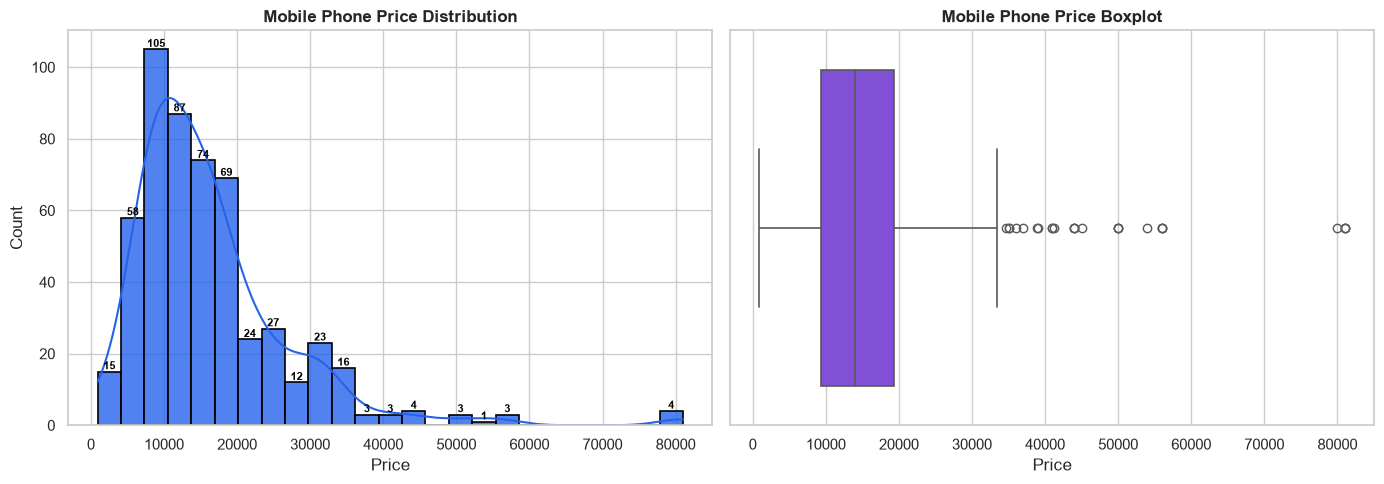

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = sns.histplot(
    data=df, x="Price", bins=25, kde=True,
    color="#2563EB", edgecolor="black",
    linewidth=1.2, alpha=0.8, ax=axes[0]
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha="center", va="bottom",
            fontsize=8, fontweight="bold", color="black"
        )

axes[0].set_title("Mobile Phone Price Distribution", fontweight="bold")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")

sns.boxplot(
    data=df, x="Price",
    color="#7C3AED",
    linewidth=1.2,
    ax=axes[1]
)

axes[1].set_title("Mobile Phone Price Boxplot", fontweight="bold")
axes[1].set_xlabel("Price")

plt.tight_layout()
plt.show()


Model Distribution
Model
realme C55               9
REDMI Note 12 Pro 5G     9
vivo Y16                 9
SAMSUNG Galaxy A14 5G    9
Infinix HOT 30i          8
                        ..
SAMSUNG Galaxy A04e      1
SAMSUNG Galaxy S23 5G    1
LAVA Z21                 1
Tecno Spark 8T           1
OPPO A77                 1
Name: count, Length: 187, dtype: int64


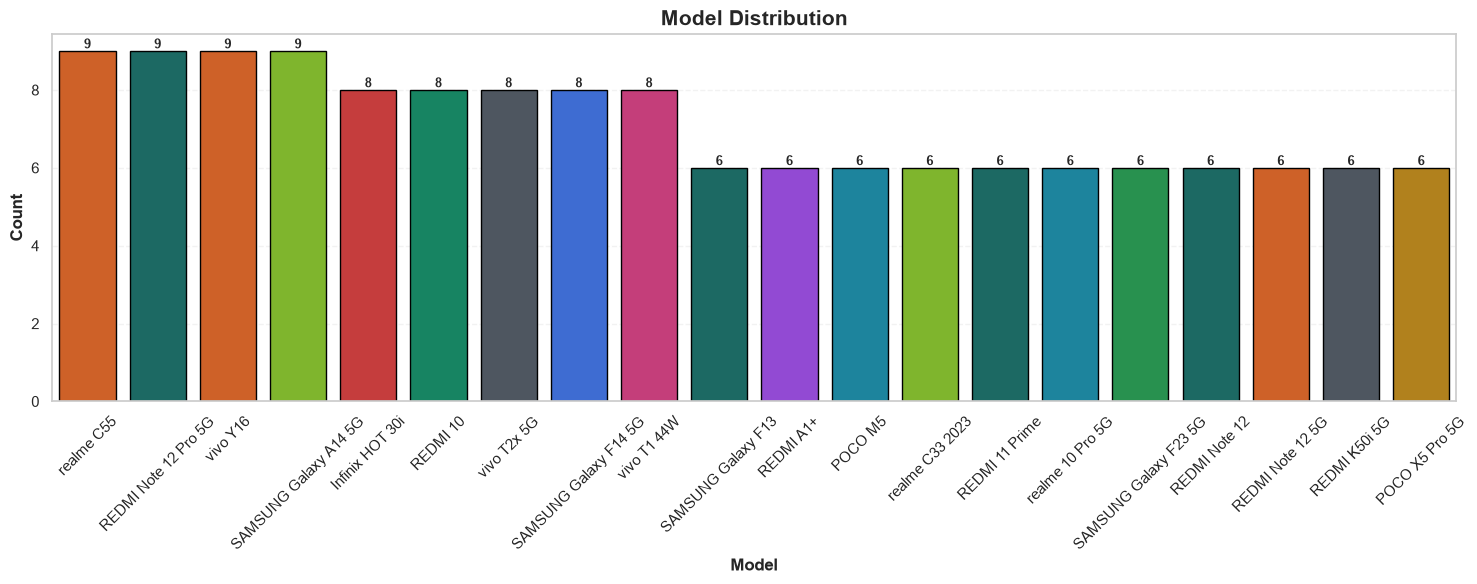


Colour Distribution
Colour
Yellow             12
Royal Blue          8
Power Black         8
Black               8
Cool Blue           7
                   ..
Starlight Black     1
Cream               1
Cyan                1
Awesome Lime        1
Sky Blue            1
Name: count, Length: 275, dtype: int64


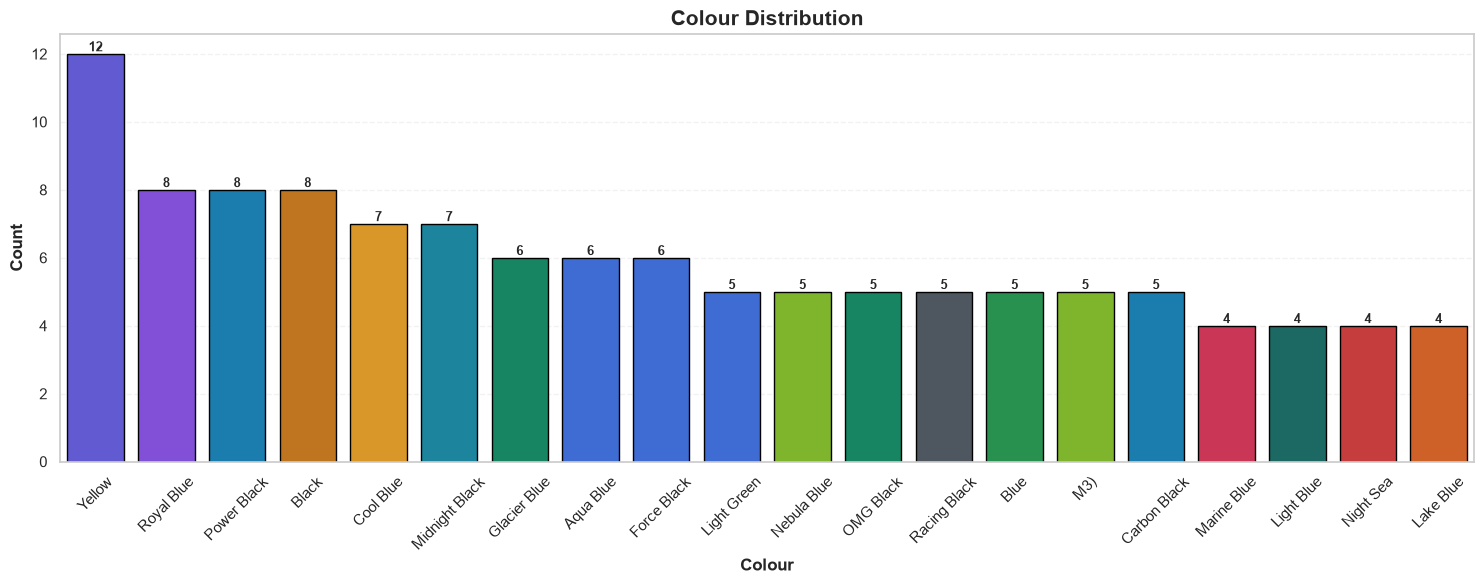


Processor Type Distribution
Processor_Type
Qualcomm Snapdragon 680                     33
Unisoc T612                                 21
Mediatek Helio A22                          19
Mediatek Dimensity 1080                     18
Qualcomm Snapdragon 695 5G                  17
                                            ..
6 Core                                       1
Dimensity 8200                               1
Qualcomm SM6225 Snapdragon 680 4G (6 nm)     1
Exynos Octa Core                             1
Qualcomm Snapdragon 8 Gen 2                  1
Name: count, Length: 123, dtype: int64


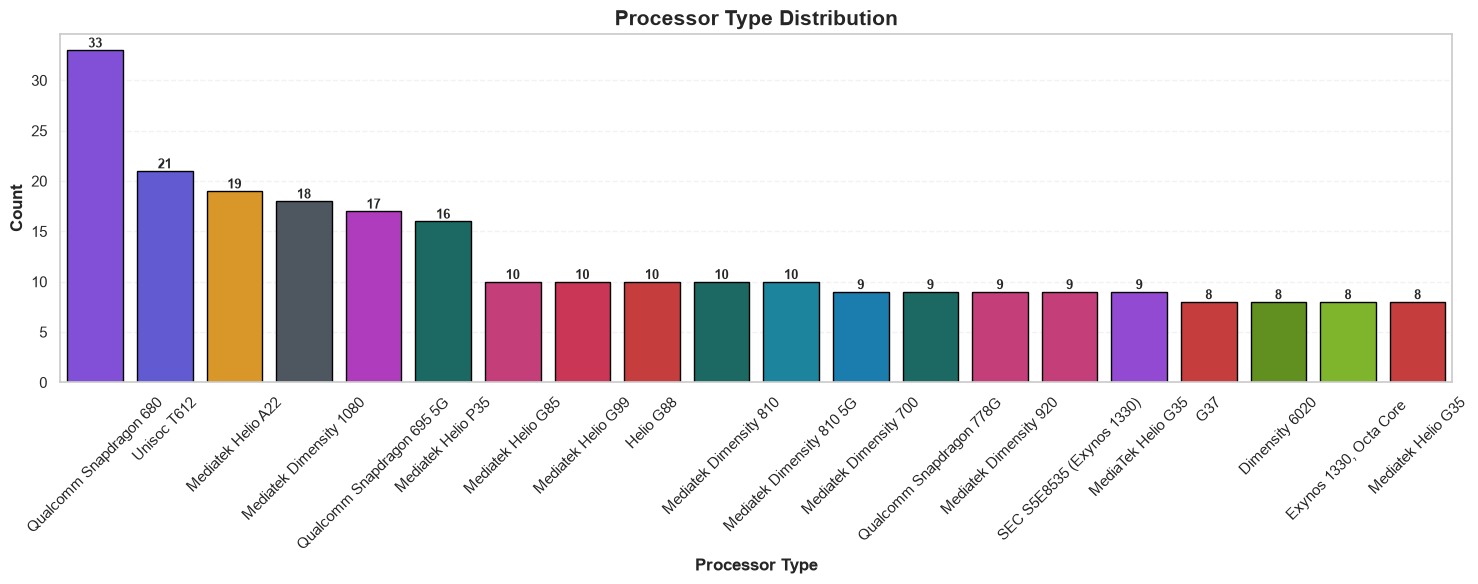


Brand From Model Distribution
brand_from_model
realme      98
redmi       75
infinix     65
vivo        62
poco        60
samsung     55
motorola    46
tecno       17
oppo        16
micromax    14
google       9
oneplus      5
apple        5
itel         3
nokia        3
nothing      2
i kall       2
iqoo         2
lava         2
Name: count, dtype: Int64


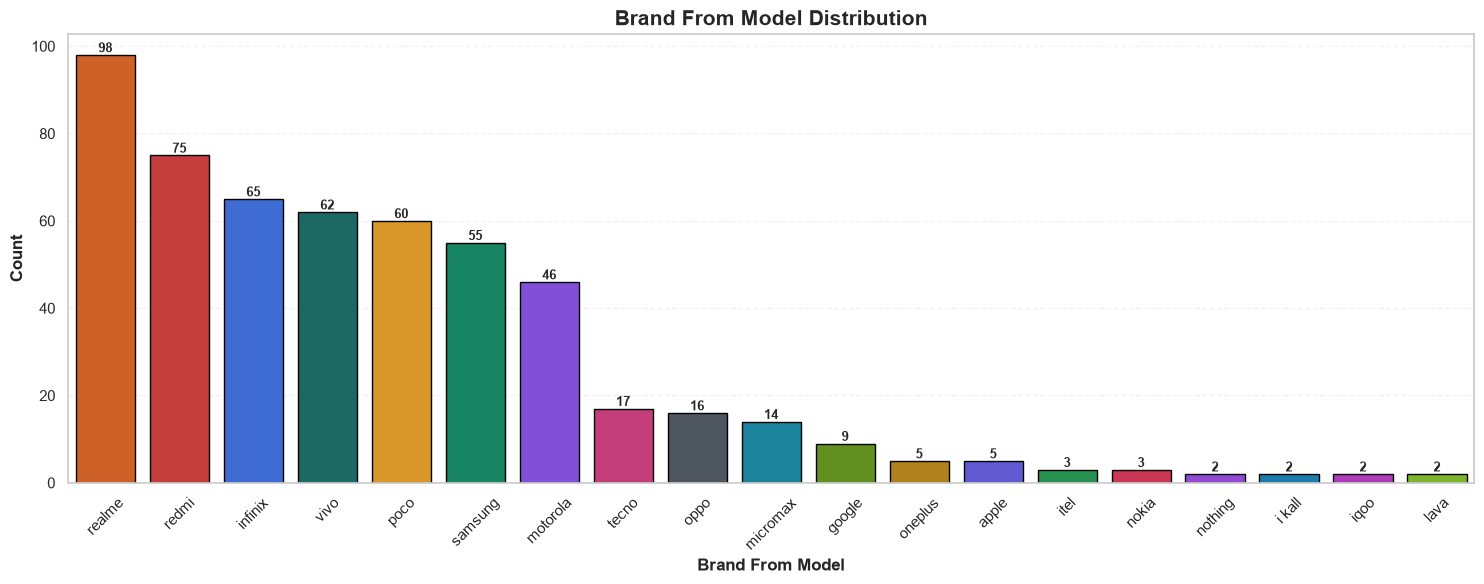


Processor Family Distribution
processor_family
MediaTek                   276
Qualcomm Snapdragon        130
UNISOC/Spreadtrum           71
Samsung Exynos              30
Other/Unspecified           17
Generic Core Descriptor      9
Google Tensor                8
Name: count, dtype: int64


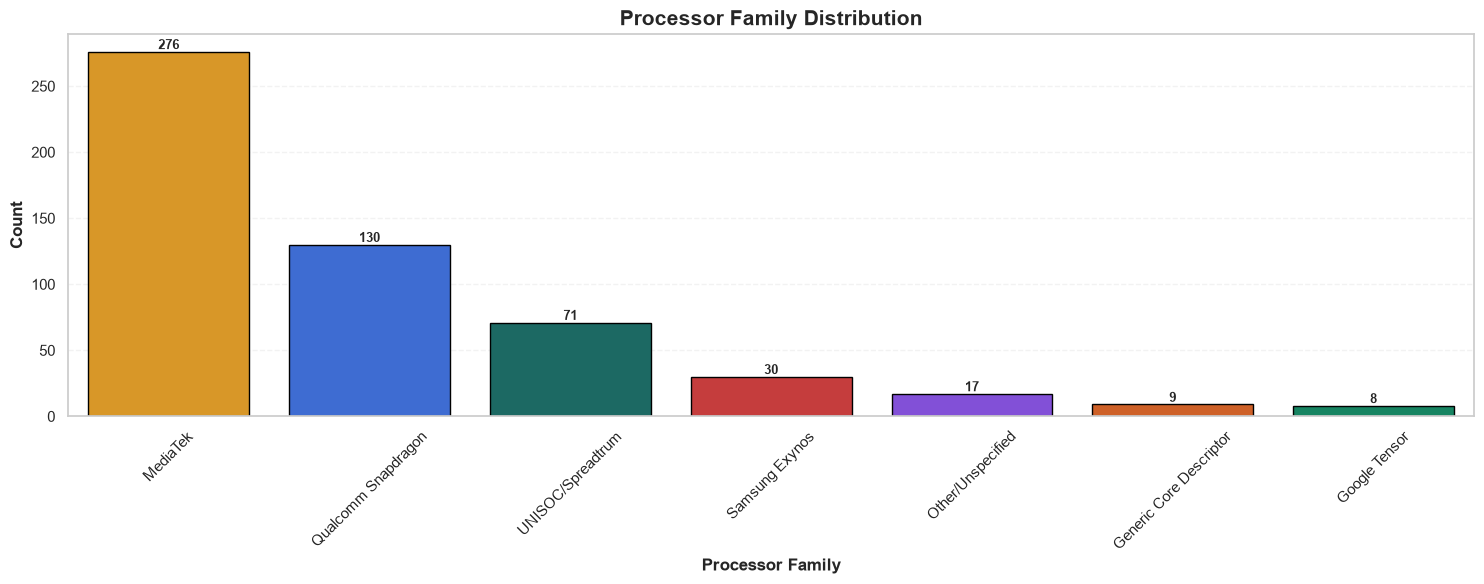


Memory Tier Distribution
memory_tier
High        259
Standard    169
Entry        58
Ultra        55
Name: count, dtype: int64


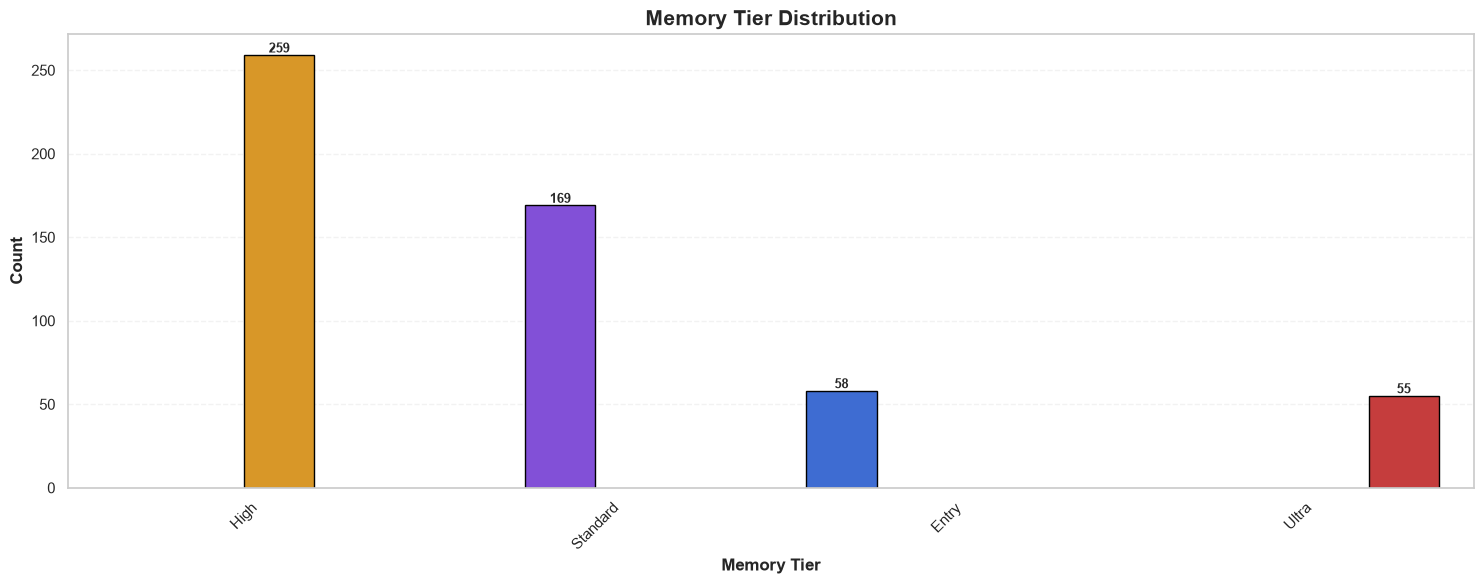


Ram Tier Distribution
ram_tier
Standard    226
Ultra       157
High        121
Entry        37
Name: count, dtype: int64


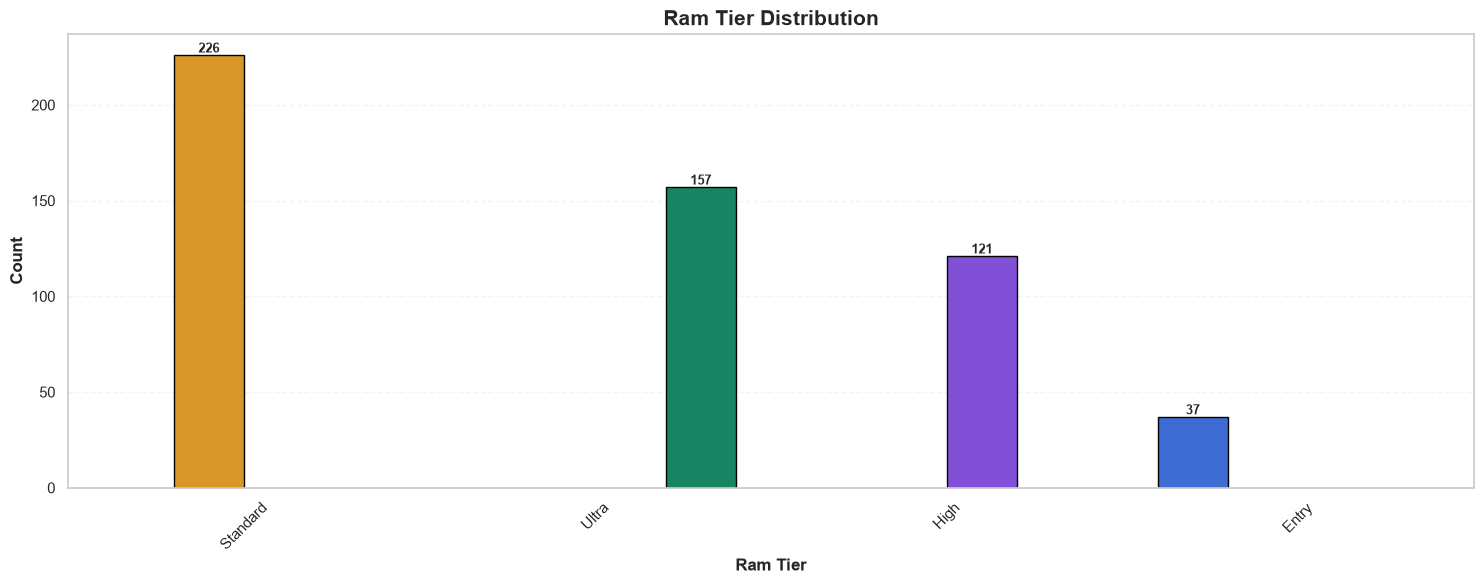


Battery Tier Distribution
battery_tier
High         419
Standard      60
Very High     43
Low           19
Name: count, dtype: int64


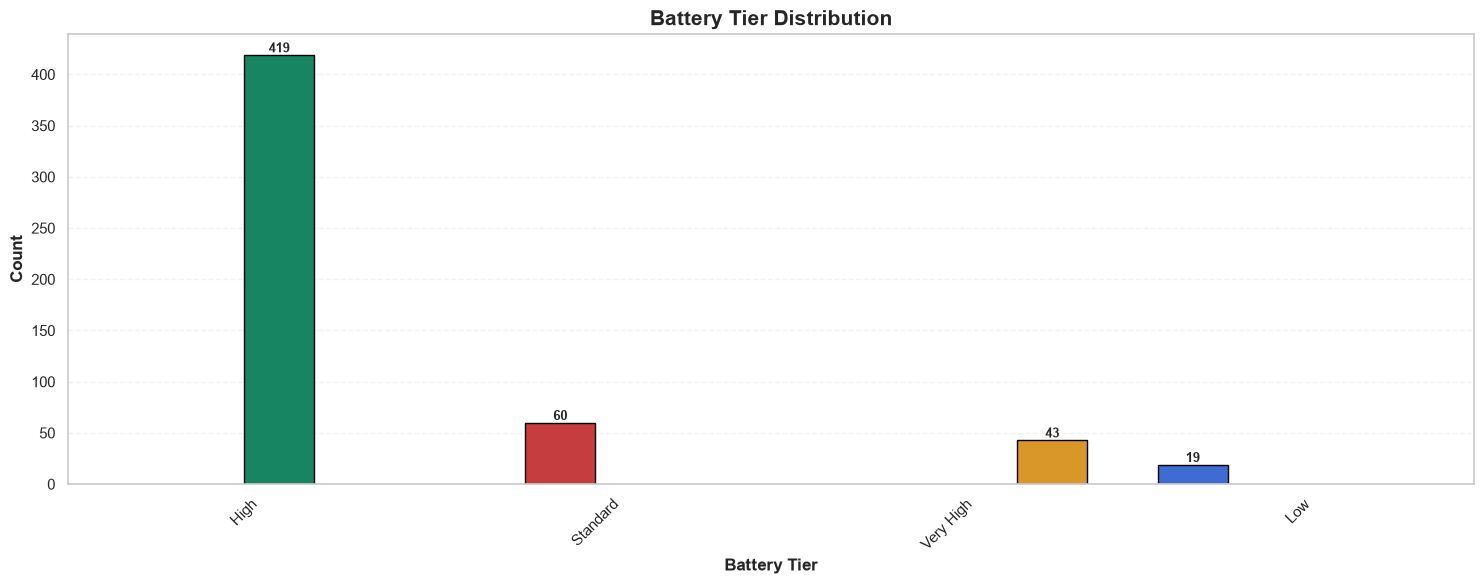


Camera Tier Distribution
camera_tier
High        219
Advanced    165
Standard    100
Ultra        38
Basic        19
Name: count, dtype: int64


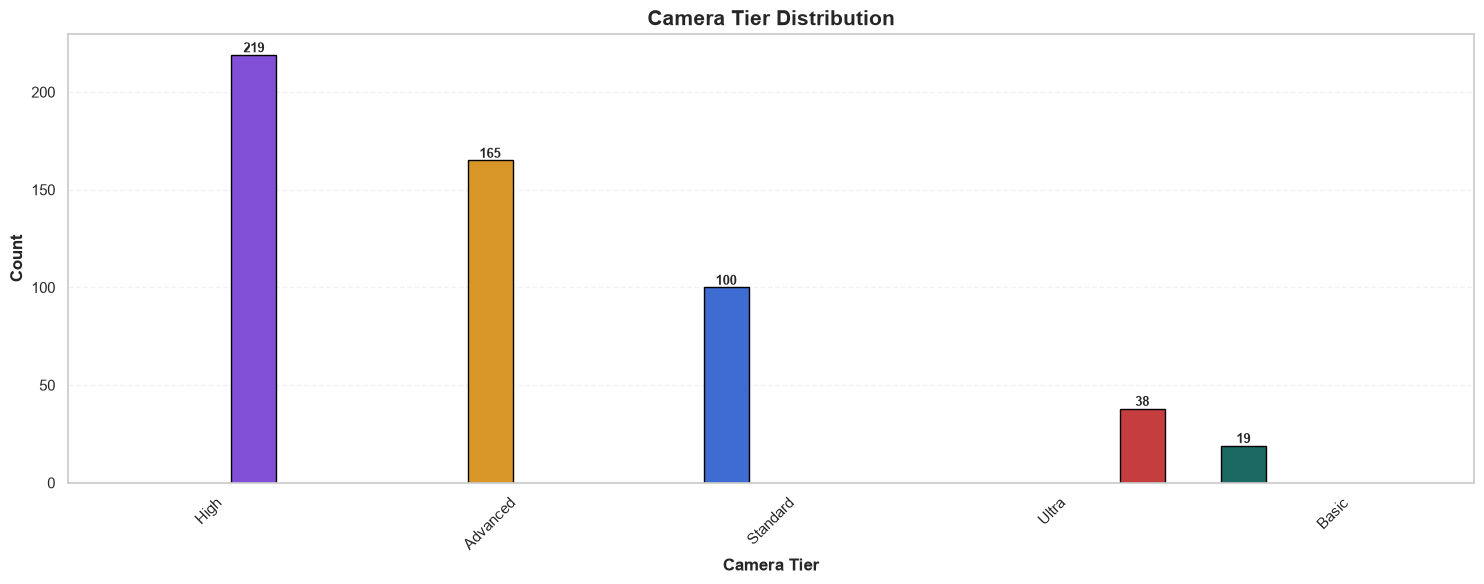

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_colors = {
    "Model": ["#2563EB","#7C3AED","#F59E0B","#DC2626","#059669","#0F766E","#EA580C","#0891B2","#65A30D","#4B5563","#DB2777","#9333EA","#0284C7","#16A34A","#CA8A04","#C026D3","#E11D48","#4F46E5","#0891B2","#84CC16"],
    "Colour": ["#0F766E","#2563EB","#F59E0B","#7C3AED","#DC2626","#059669","#EA580C","#0891B2","#65A30D","#4B5563","#DB2777","#9333EA","#0284C7","#16A34A","#CA8A04","#C026D3","#E11D48","#4F46E5","#84CC16","#D97706"],
    "Processor_Type": ["#2563EB","#7C3AED","#F59E0B","#DC2626","#059669","#0F766E","#EA580C","#0891B2","#65A30D","#4B5563","#DB2777","#9333EA","#0284C7","#16A34A","#CA8A04","#C026D3","#E11D48","#4F46E5","#84CC16","#D97706"],
    "brand_from_model": ["#2563EB","#7C3AED","#F59E0B","#DC2626","#059669","#0F766E","#EA580C","#0891B2","#65A30D","#4B5563","#DB2777","#9333EA","#0284C7","#16A34A","#CA8A04","#C026D3","#E11D48","#4F46E5","#84CC16"],
    "processor_family": ["#0F766E","#2563EB","#F59E0B","#7C3AED","#DC2626","#059669","#EA580C"],
    "memory_tier": ["#2563EB","#7C3AED","#F59E0B","#DC2626"],
    "ram_tier": ["#2563EB","#F59E0B","#7C3AED","#059669"],
    "battery_tier": ["#2563EB","#DC2626","#059669","#F59E0B"],
    "camera_tier": ["#0F766E","#2563EB","#F59E0B","#7C3AED","#DC2626"]
}

for col, colors in cat_colors.items():

    data = df_fe if col in df_fe.columns else df
    if col not in data.columns:
        continue

    # Distribution output
    print(f"\n{col.replace('_', ' ').title()} Distribution")
    print(data[col].value_counts())

    order = data[col].dropna().value_counts().head(20).index
    plt.figure(figsize=(15,6))

    ax = sns.countplot(
        data=data, x=col, order=order, hue=col,
        palette=colors, legend=False, edgecolor="black"
    )

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(
                int(p.get_height()),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom",
                fontsize=9, fontweight="bold"
            )

    ax.set_title(
        f"{col.replace('_',' ').title()} Distribution",
        fontsize=15, fontweight="bold"
    )
    ax.set_xlabel(
        col.replace("_"," ").title(),
        fontsize=12, fontweight="bold"
    )
    ax.set_ylabel("Count", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=.25)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

## 18. Bivariate Analysis

Feature-versus-price plots help identify monotonic relationships, nonlinear patterns, clusters, and potential data-quality issues.

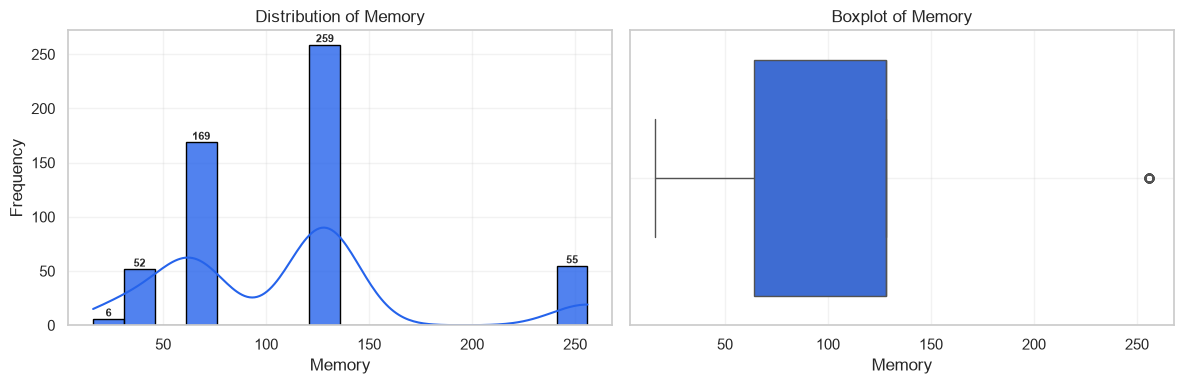

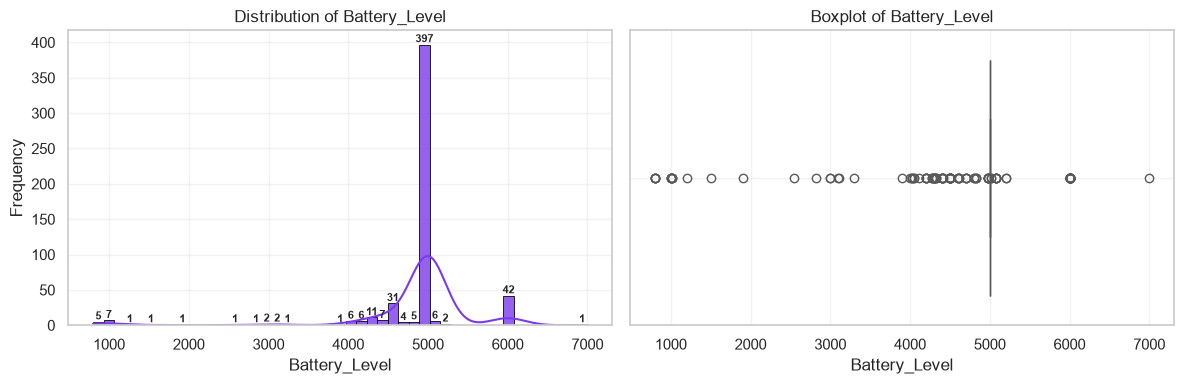

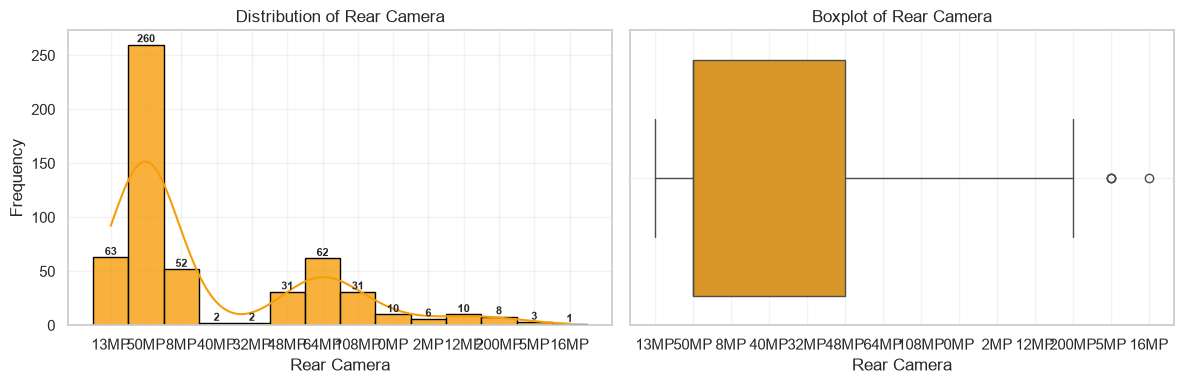

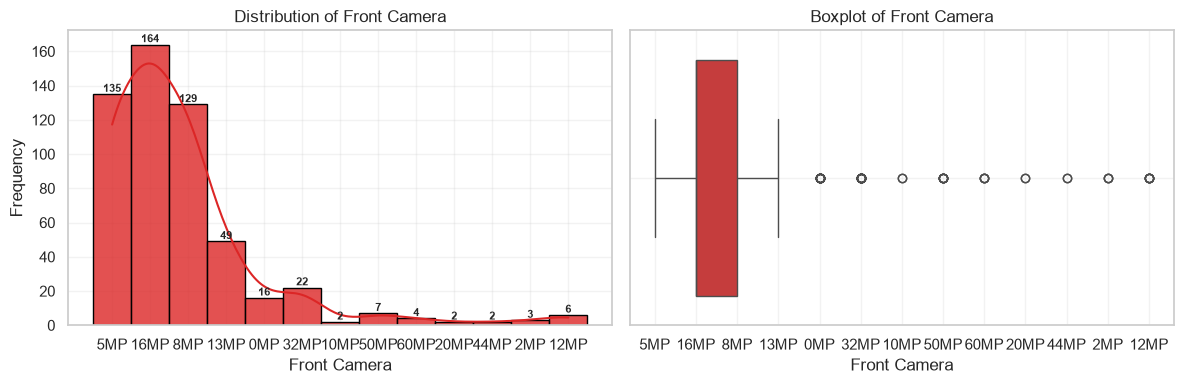

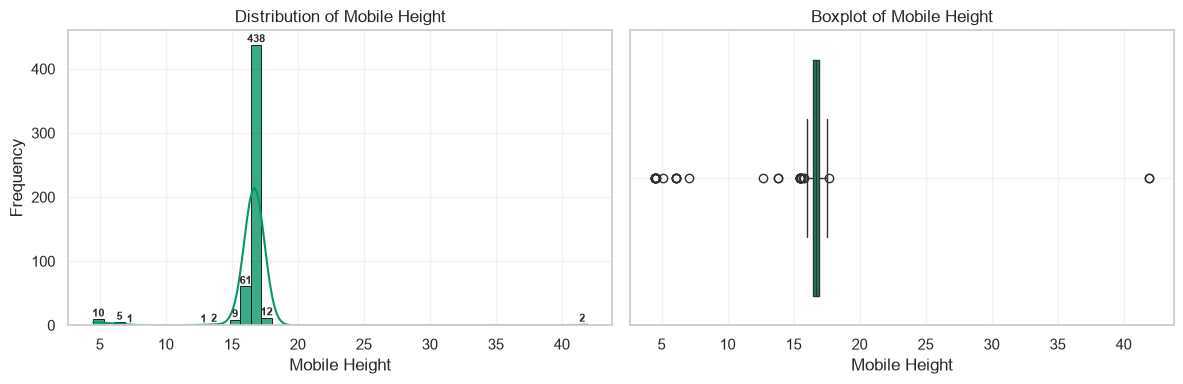

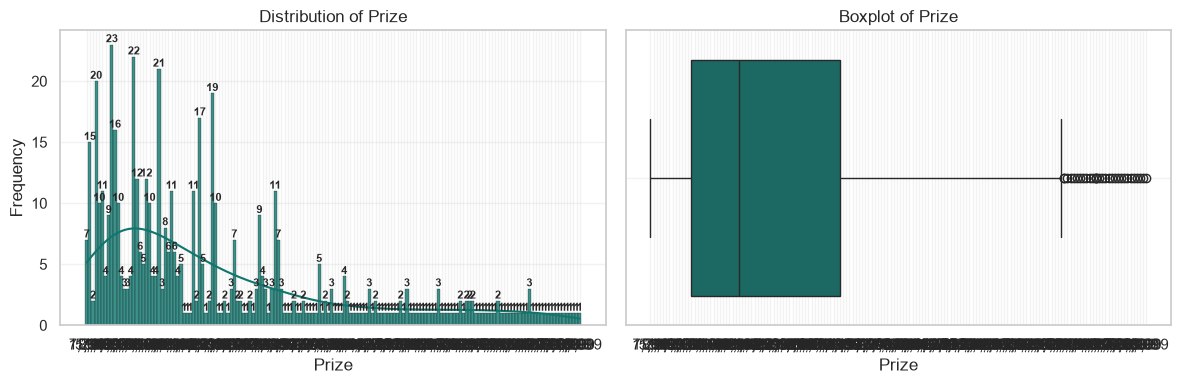

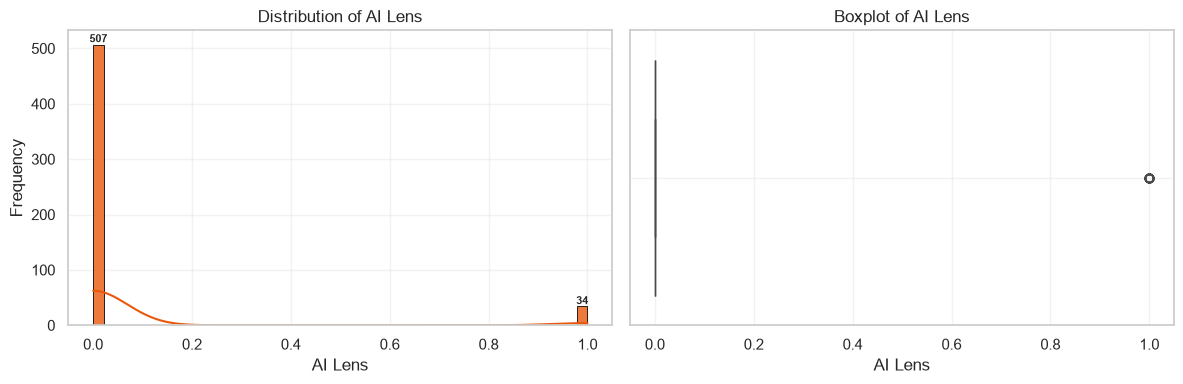

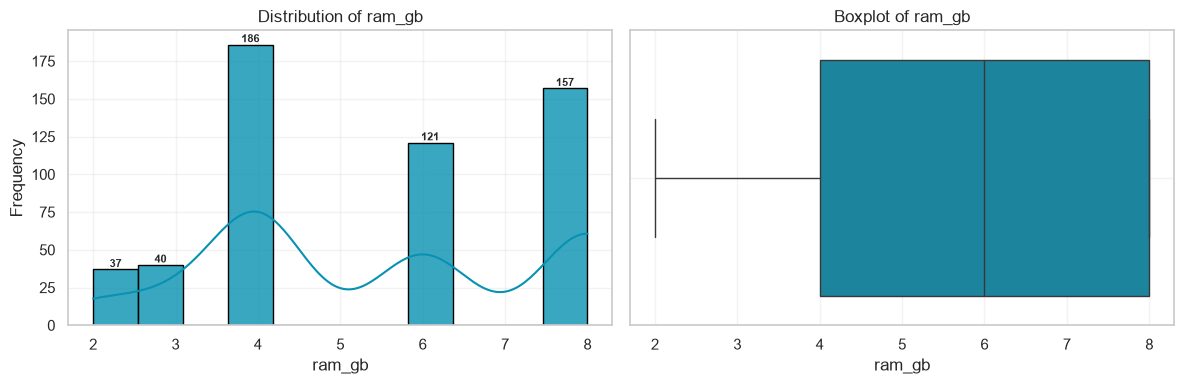

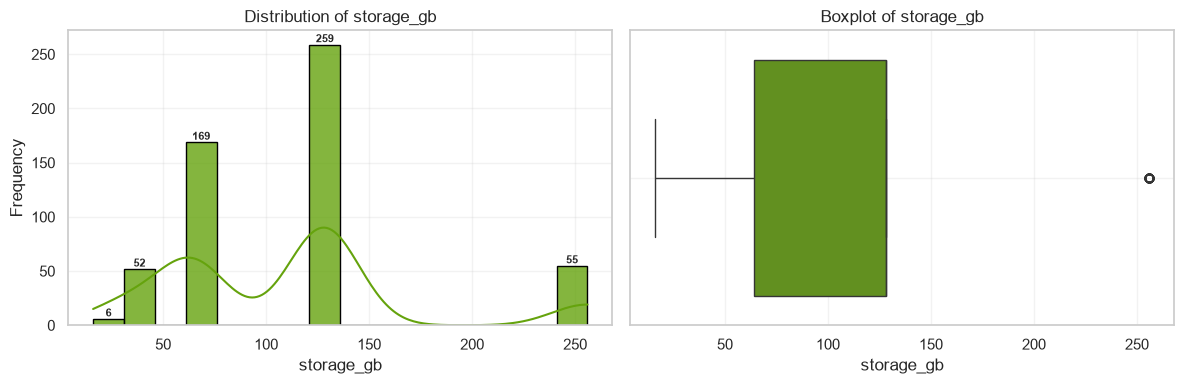

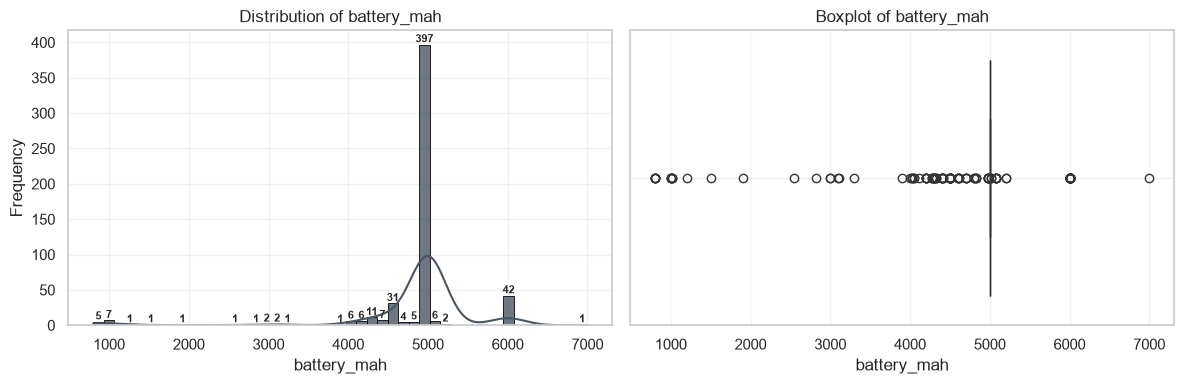

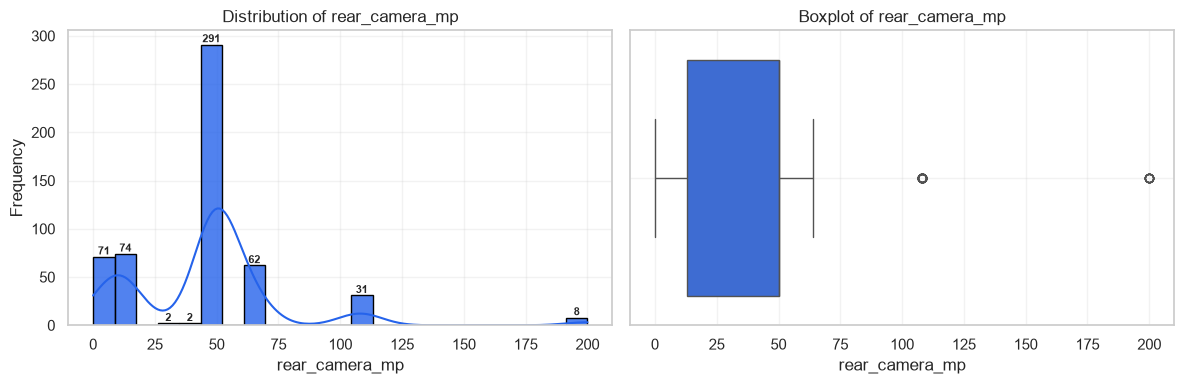

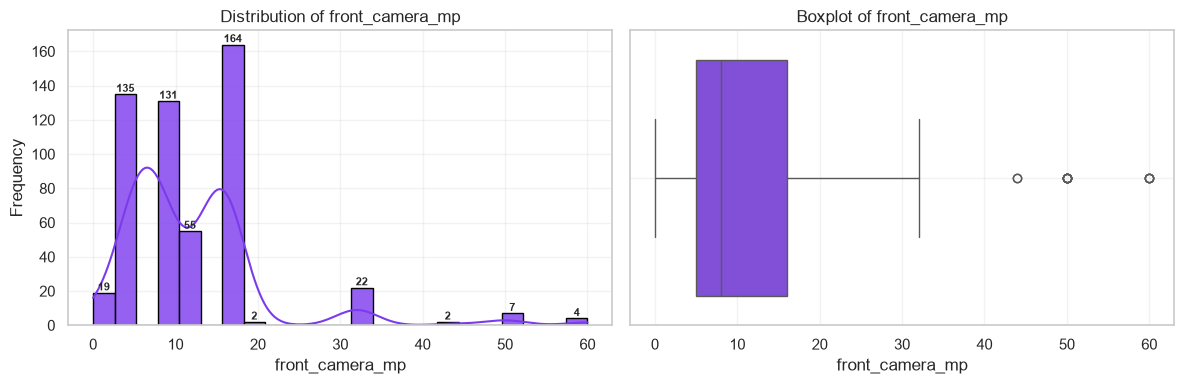

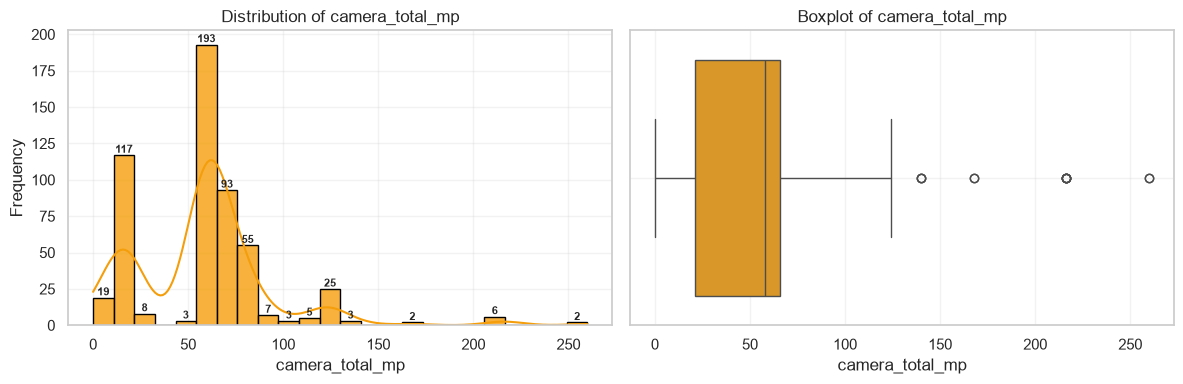

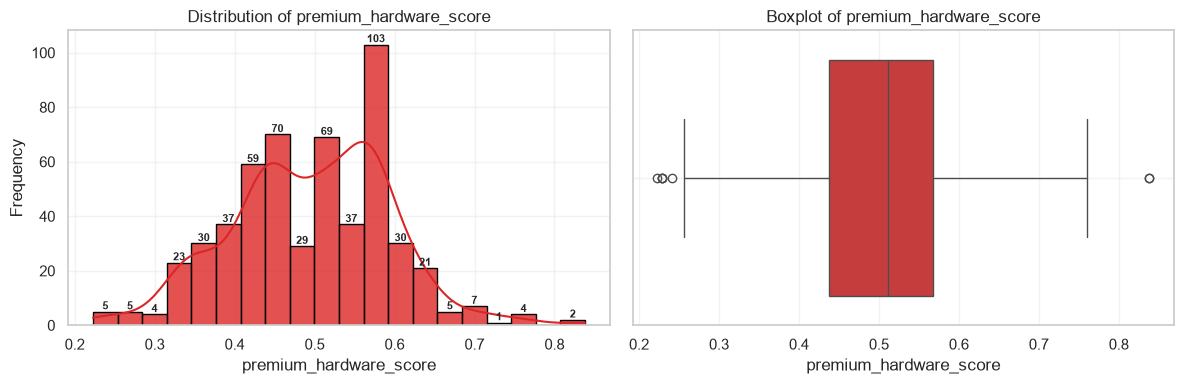

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Convert AI Lens to numeric
df_fe["AI Lens"] = pd.to_numeric(df_fe["AI Lens"], errors="coerce")

numeric_cols = [
    "Memory","Battery_Level","Rear Camera","Front Camera","Mobile Height","Prize",
    "AI Lens","ram_gb","storage_gb","battery_mah","rear_camera_mp",
    "front_camera_mp","camera_total_mp","premium_hardware_score"
]

colors = [
    "#2563EB","#7C3AED","#F59E0B","#DC2626","#059669",
    "#0F766E","#EA580C","#0891B2","#65A30D","#4B5563"
]

for i, col in enumerate(numeric_cols):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    c = colors[i % len(colors)]

    ax = sns.histplot(
        df_fe[col].dropna(),
        kde=True,
        color=c,
        edgecolor="black",
        alpha=.8,
        ax=axes[0]
    )

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(
                f"{int(p.get_height())}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold"
            )

    axes[0].set(
        title=f"Distribution of {col}",
        xlabel=col,
        ylabel="Frequency"
    )

    sns.boxplot(
        x=df_fe[col].dropna(),
        color=c,
        ax=axes[1]
    )

    axes[1].set(
        title=f"Boxplot of {col}",
        xlabel=col
    )

    for ax in axes:
        ax.set_facecolor("white")
        ax.grid(True, axis="both", linestyle="-", alpha=.25)
        ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

## 19. Multivariate Analysis

A single specification rarely explains price on its own. Multivariate plots help reveal how RAM, storage, battery, camera capability, and price interact.

In [57]:
import pandas as pd

# Create Price Segment safely
price_col = "Prize"

if price_col in df.columns:

    df["Price Segment"] = pd.cut(
        df[price_col],
        bins=[0, 10000, 20000, float("inf")],
        labels=["Budget", "Mid-Range", "Premium"],
        include_lowest=True
    )

    print(df.head(10))

else:
    print(f"Column '{price_col}' not found.")
    print("Available columns:")
    print(df.columns.tolist())

Column 'Prize' not found.
Available columns:
['Model', 'Colour', 'Memory', 'RAM', 'Battery_Level', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Price']


In [58]:
df.drop(columns=["Price Segment"], errors="ignore", inplace=True)

df.head(10)

,Model,Colour,Memory,RAM,Battery_Level,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Price
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999
5,Infinix HOT 30i,Glacier Blue,128,8,5000,50MP,5MP,1,16.76,G37,8999
6,Infinix HOT 30i,Mirror Black,128,8,5000,50MP,5MP,1,16.76,G37,8999
7,Infinix HOT 30i,Diamond White,128,8,5000,50MP,5MP,1,16.76,G37,8999
8,Infinix HOT 30i,Diamond White,64,4,5000,50MP,5MP,1,16.76,G37,7999
9,Infinix HOT 30i,Mirror Black,64,4,5000,50MP,5MP,1,16.76,G37,7999


In [59]:
print("Number of rows and columns:", df.shape)

print("\nActual column names:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

Number of rows and columns: (531, 11)

Actual column names:
0 'Model'
1 'Colour'
2 'Memory'
3 'RAM'
4 'Battery_Level'
5 'Rear Camera'
6 'Front Camera'
7 'AI Lens'
8 'Mobile Height'
9 'Processor_'
10 'Price'


In [60]:
import pandas as pd
import numpy as np

# ============================================================
# FEATURE ENGINEERING - CORRECTED FOR YOUR DATASET
# ============================================================

# Work on a copy
data = df.copy()

# Clean column names
data.columns = data.columns.astype(str).str.strip()

print("Original shape:", data.shape)
print("Columns:", data.columns.tolist())


# ============================================================
# 1. Convert numeric columns
# ============================================================

numeric_cols = [
    "Memory",
    "RAM",
    "Battery_Level",
    "Rear Camera",
    "Front Camera",
    "Price"
]

for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )

# Fill missing numeric values
for col in numeric_cols:
    if col in data.columns:
        data[col] = data[col].fillna(0)


# ============================================================
# 2. Total Camera MP
# ============================================================

data["Total Camera MP"] = (
    data["Rear Camera"] +
    data["Front Camera"]
)


# ============================================================
# 3. Brand from Model
# ============================================================

data["Brand"] = (
    data["Model"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.split()
    .str[0]
)


# ============================================================
# 4. Processor Brand
# ============================================================

data["Processor Brand"] = (
    data["Processor_"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.split()
    .str[0]
)


# ============================================================
# 5. Battery per GB
# ============================================================

data["Battery per GB"] = np.where(
    data["RAM"] > 0,
    data["Battery_Level"] / data["RAM"],
    0
)


# ============================================================
# 6. Memory per GB
# ============================================================

data["Memory per GB"] = np.where(
    data["RAM"] > 0,
    data["Memory"] / data["RAM"],
    0
)


# ============================================================
# 7. Gaming Phone
# ============================================================

processor_text = (
    data["Processor_"]
    .fillna("")
    .astype(str)
)

data["Gaming Phone"] = (
    (data["RAM"] >= 8) &
    (data["Battery_Level"] >= 5000) &
    processor_text.str.contains(
        "Snapdragon|Dimensity|Helio G",
        case=False,
        regex=True,
        na=False
    )
).astype(int)


# ============================================================
# 8. Camera Phone
# ============================================================

data["Camera Phone"] = (
    (data["Rear Camera"] >= 64) &
    (data["Front Camera"] >= 16)
).astype(int)


# ============================================================
# 9. Performance Phone
# ============================================================

data["Performance Phone"] = (
    data["RAM"] >= 8
).astype(int)


# ============================================================
# 10. Budget Phone
# ============================================================

data["Budget Phone"] = (
    data["Price"] <= 10000
).astype(int)


# ============================================================
# 11. Price Segment
# ============================================================

data["Price Segment"] = pd.cut(
    data["Price"],
    bins=[-np.inf, 10000, 20000, np.inf],
    labels=[
        "Budget",
        "Mid-Range",
        "Premium"
    ],
    include_lowest=True
)


# ============================================================
# 12. Put Price Segment immediately after Price
# ============================================================

cols = data.columns.tolist()

cols.remove("Price Segment")

price_position = cols.index("Price") + 1

cols.insert(
    price_position,
    "Price Segment"
)

data = data[cols]


# ============================================================
# 13. Update df
# ============================================================

df = data.copy()




Original shape: (531, 11)
Columns: ['Model', 'Colour', 'Memory', 'RAM', 'Battery_Level', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Price']


In [61]:
print("\nFirst 20 rows:")
display(df.head(20))


First 20 rows:


,Model,Colour,Memory,RAM,Battery_Level,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Price,Price Segment,Total Camera MP,Brand,Processor Brand,Battery per GB,Memory per GB,Gaming Phone,Camera Phone,Performance Phone,Budget Phone
0,Infinix SMART 7,Night Black,64,4,6000,0.0,0.0,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Budget,0.0,Infinix,Unisoc,1500.0,16.0,0,0,0,1
1,Infinix SMART 7,Azure Blue,64,4,6000,0.0,0.0,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Budget,0.0,Infinix,Unisoc,1500.0,16.0,0,0,0,1
2,MOTOROLA G32,Mineral Gray,128,8,5000,0.0,0.0,0,16.64,Qualcomm Snapdragon 680,11999,Mid-Range,0.0,MOTOROLA,Qualcomm,625.0,16.0,1,0,1,0
3,POCO C50,Royal Blue,32,2,5000,0.0,0.0,0,16.56,Mediatek Helio A22,5649,Budget,0.0,POCO,Mediatek,2500.0,16.0,0,0,0,1
4,Infinix HOT 30i,Marigold,128,8,5000,0.0,0.0,1,16.76,G37,8999,Budget,0.0,Infinix,G37,625.0,16.0,0,0,1,1
5,Infinix HOT 30i,Glacier Blue,128,8,5000,0.0,0.0,1,16.76,G37,8999,Budget,0.0,Infinix,G37,625.0,16.0,0,0,1,1
6,Infinix HOT 30i,Mirror Black,128,8,5000,0.0,0.0,1,16.76,G37,8999,Budget,0.0,Infinix,G37,625.0,16.0,0,0,1,1
7,Infinix HOT 30i,Diamond White,128,8,5000,0.0,0.0,1,16.76,G37,8999,Budget,0.0,Infinix,G37,625.0,16.0,0,0,1,1
8,Infinix HOT 30i,Diamond White,64,4,5000,0.0,0.0,1,16.76,G37,7999,Budget,0.0,Infinix,G37,1250.0,16.0,0,0,0,1
9,Infinix HOT 30i,Mirror Black,64,4,5000,0.0,0.0,1,16.76,G37,7999,Budget,0.0,Infinix,G37,1250.0,16.0,0,0,0,1


In [62]:
# ============================================================
# 14. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 60)
print("FEATURE ENGINEERING COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Dataset shape:", df.shape)

print("\nFinal columns:")
print(df.columns.tolist())


FEATURE ENGINEERING COMPLETED SUCCESSFULLY
Dataset shape: (531, 21)

Final columns:
['Model', 'Colour', 'Memory', 'RAM', 'Battery_Level', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Price', 'Price Segment', 'Total Camera MP', 'Brand', 'Processor Brand', 'Battery per GB', 'Memory per GB', 'Gaming Phone', 'Camera Phone', 'Performance Phone', 'Budget Phone']


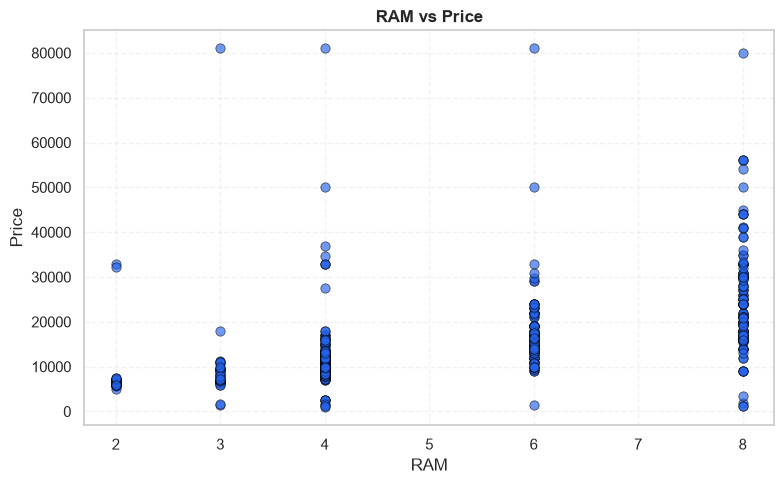

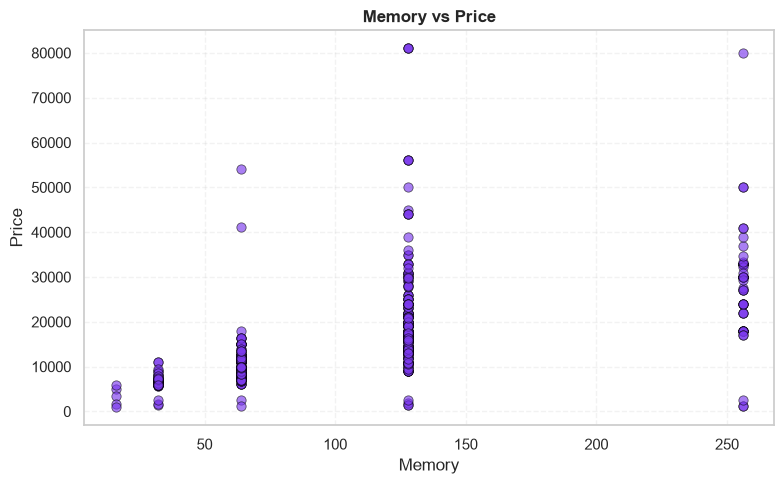

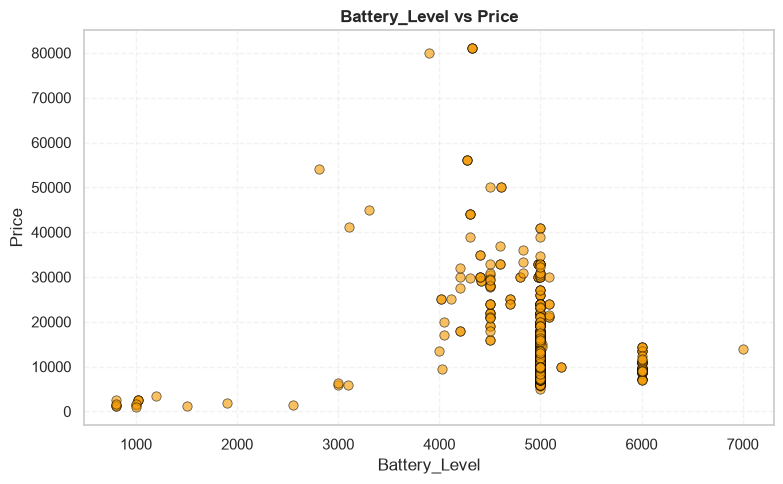

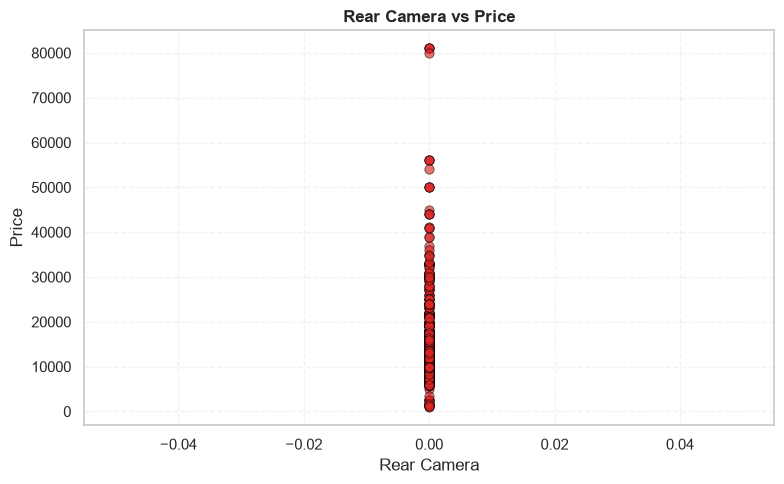

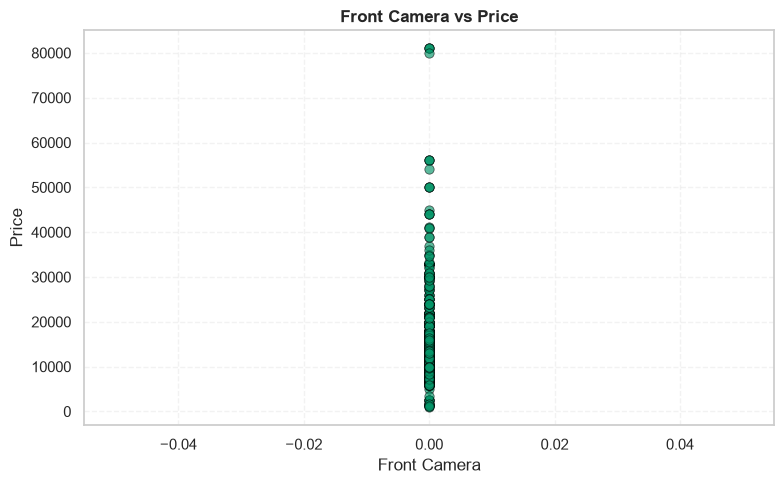

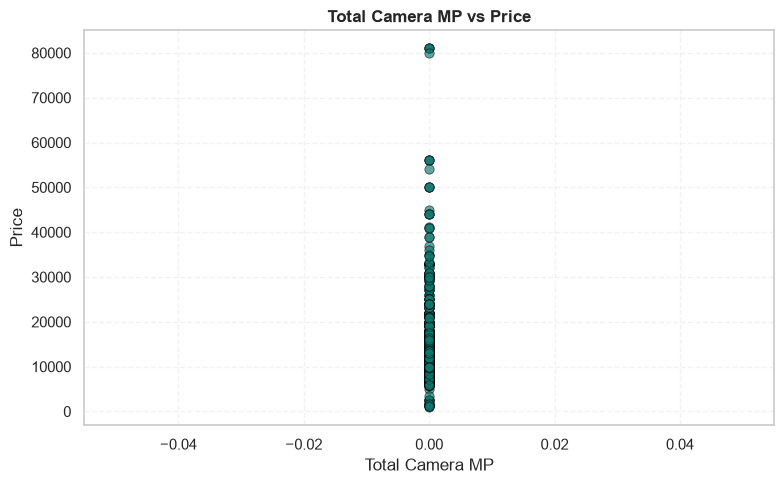

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Use 541-row dataframe
df_fe = df.copy()
df_fe.columns = df_fe.columns.astype(str).str.strip()

# Target
target = "Price" if "Price" in df_fe.columns else "Prize"

# Features
features = [
    "RAM", "Memory", "Battery_Level",
    "Rear Camera", "Front Camera", "Total Camera MP"
]

features = [c for c in features if c in df_fe.columns]

# Convert numeric
df_fe[features + [target]] = df_fe[
    features + [target]
].apply(pd.to_numeric, errors="coerce")

# Colors
colors = ["#2563EB", "#7C3AED", "#F59E0B",
          "#DC2626", "#059669", "#0F766E"]

# Scatter plots
for i, col in enumerate(features):
    d = df_fe[[col, target]].dropna()
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=d, x=col, y=target,
        color=colors[i], alpha=.65,
        edgecolor="black", s=45
    )
    plt.title(f"{col} vs {target}", fontweight="bold")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.grid(True, linestyle="--", alpha=.25)
    plt.tight_layout()
    plt.show()

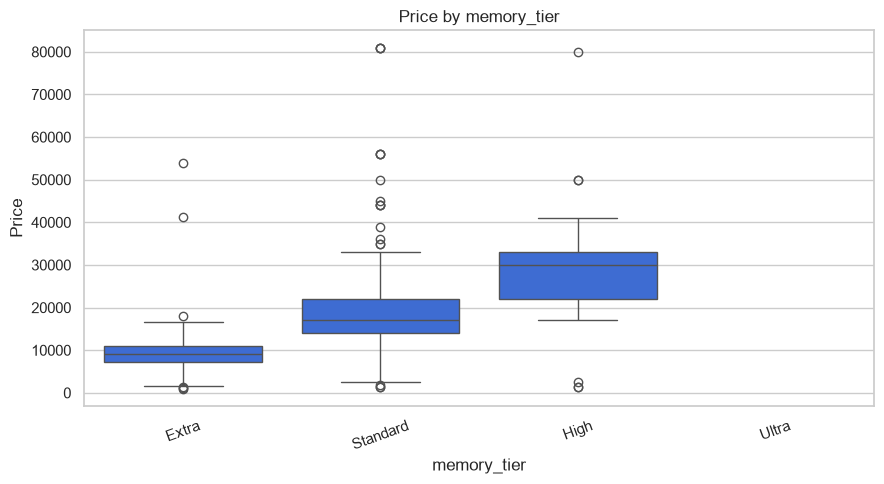

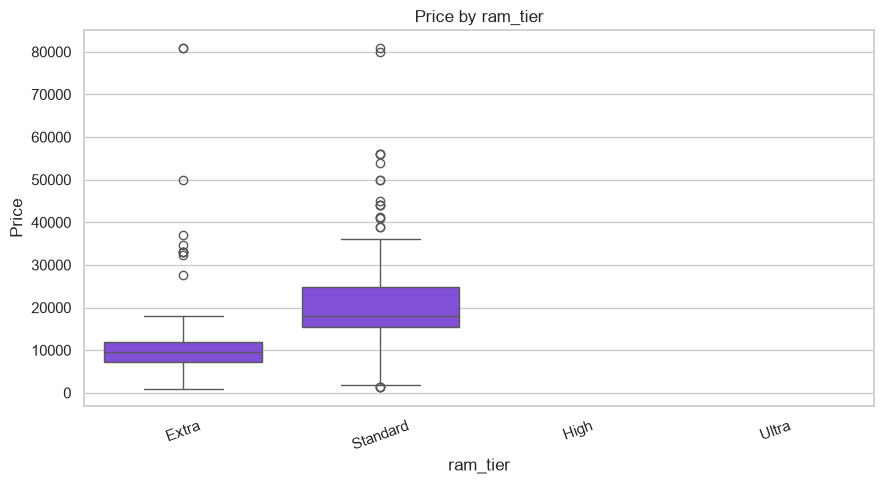

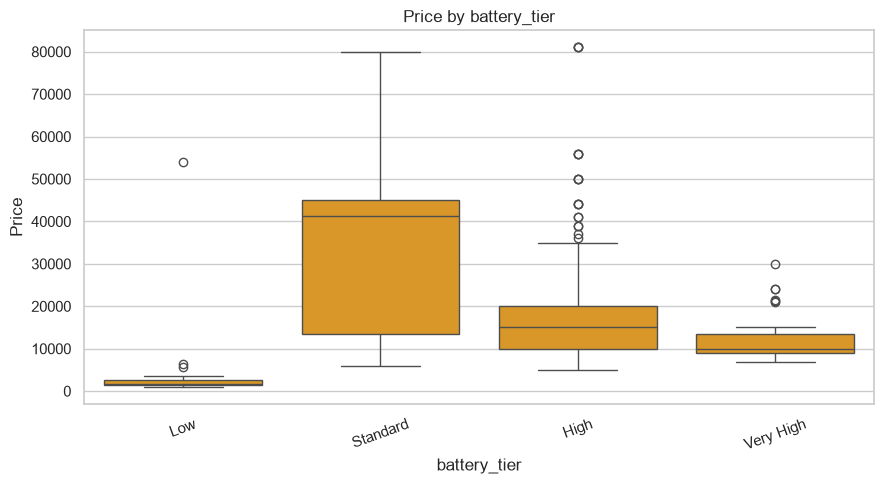

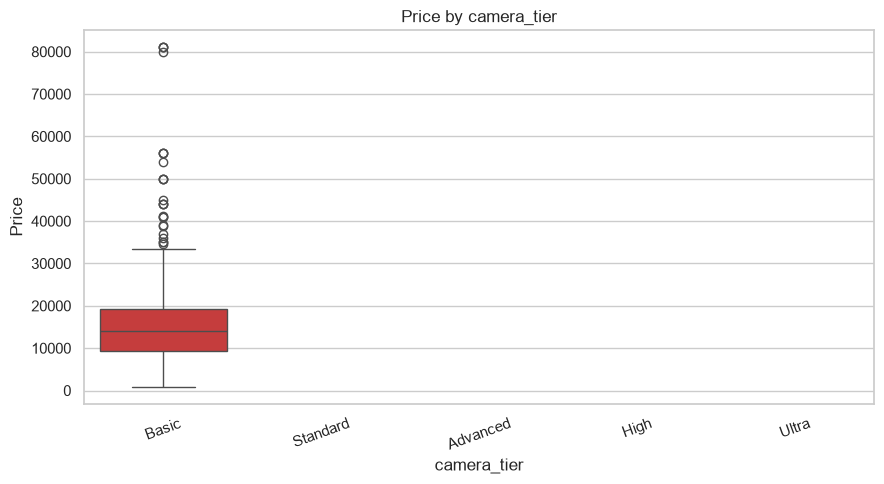

In [64]:

sns.set_theme(style="whitegrid")
df_fe = df.copy()
price = "Price" if "Price" in df_fe.columns else "Prize"

# Numeric conversion
cols = ["Memory","RAM","Battery_Level","Rear Camera","Front Camera",price]
df_fe[cols] = df_fe[cols].apply(pd.to_numeric, errors="coerce")

# Create tiers
df_fe["memory_tier"] = pd.cut(
    df_fe["Memory"], [-float("inf"),64,128,256,float("inf")],
    labels=["Extra","Standard","High","Ultra"]
)

df_fe["ram_tier"] = pd.cut(
    df_fe["RAM"], [-float("inf"),4,8,12,float("inf")],
    labels=["Extra","Standard","High","Ultra"]
)

df_fe["battery_tier"] = pd.cut(
    df_fe["Battery_Level"], [-float("inf"),3000,4000,5000,float("inf")],
    labels=["Low","Standard","High","Very High"]
)

df_fe["camera_tier"] = pd.cut(
    df_fe["Rear Camera"] + df_fe["Front Camera"],
    [-float("inf"),16,32,64,108,float("inf")],
    labels=["Basic","Standard","Advanced","High","Ultra"]
)

# Colors
colors = ["#2563EB","#7C3AED","#F59E0B","#DC2626"]

# Boxplots
tiers = ["memory_tier","ram_tier","battery_tier","camera_tier"]

for i, col in enumerate(tiers):
    plt.figure(figsize=(9,5))
    sns.boxplot(data=df_fe, x=col, y=price, color=colors[i])
    plt.title(f"Price by {col}")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

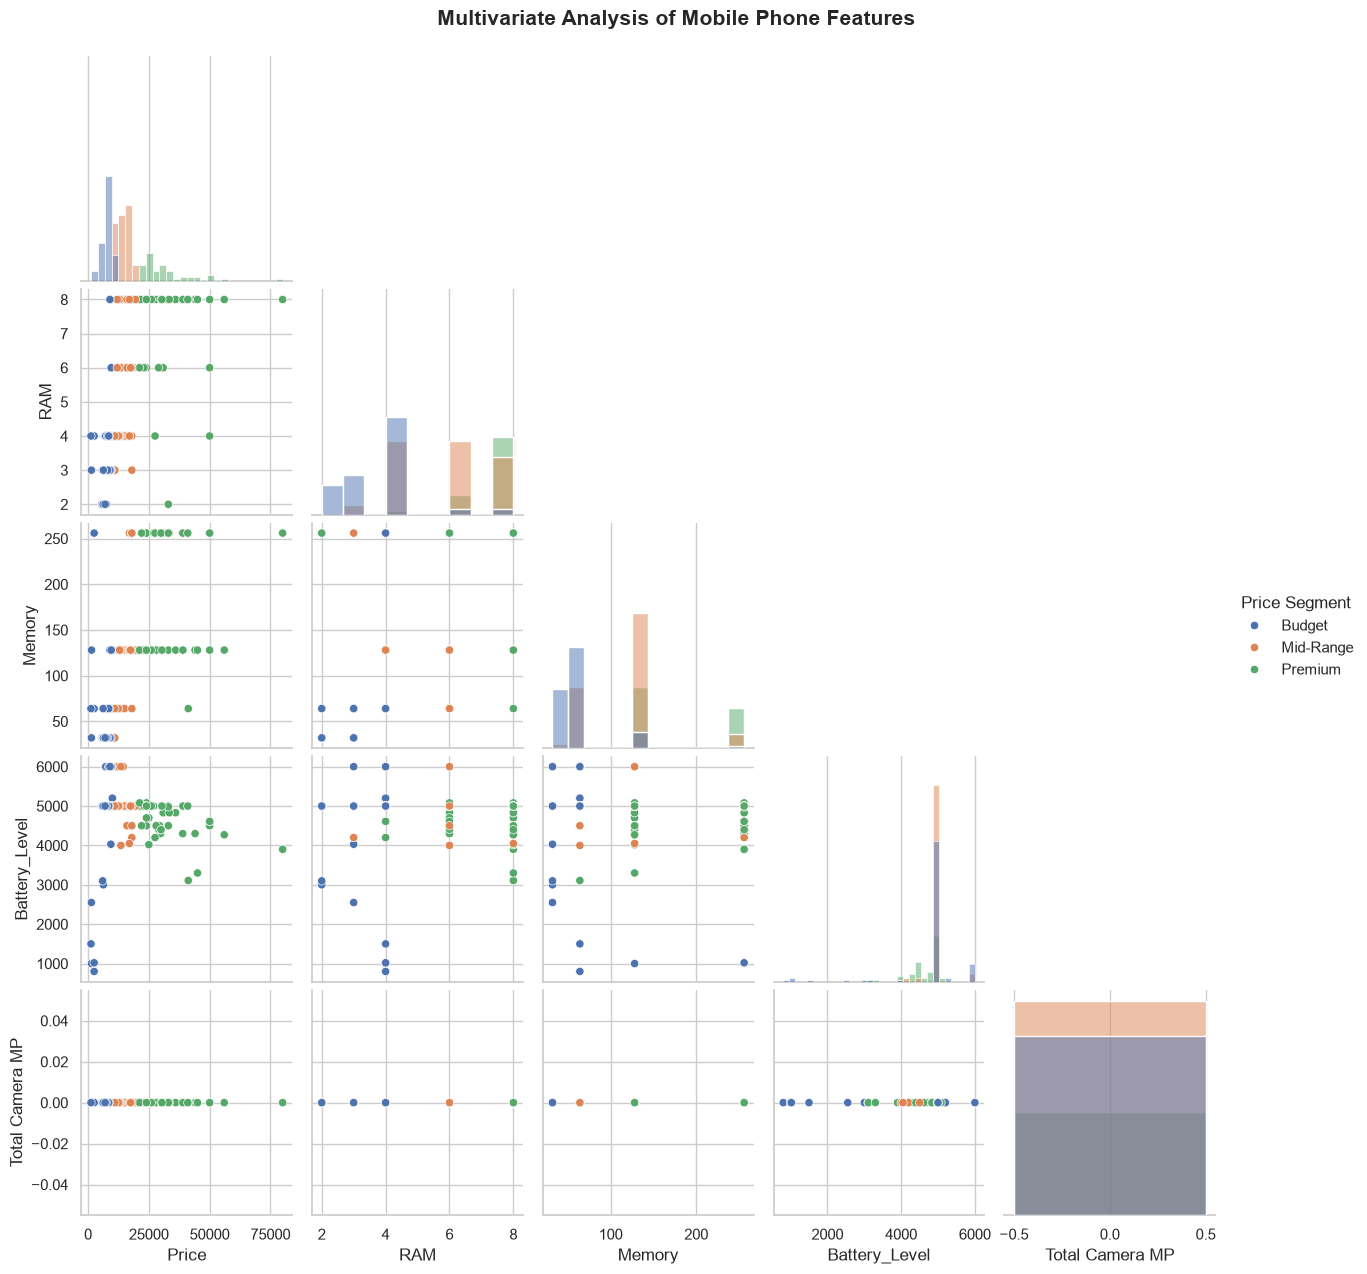

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_cols = [
    "Price", "RAM", "Memory", "Battery_Level",
    "Total Camera MP"
]

pair_cols = [c for c in pair_cols if c in df.columns]

pair_sample = df[pair_cols + ["Price Segment"]].dropna()

if len(pair_sample) > 250:
    pair_sample = pair_sample.sample(250, random_state=42)

sns.pairplot(
    pair_sample,
    vars=pair_cols,
    hue="Price Segment",
    corner=True,
    diag_kind="hist"
)

plt.suptitle(
    "Multivariate Analysis of Mobile Phone Features",
    y=1.02,
    fontsize=15,
    fontweight="bold"
)

plt.show()

## 20. Correlation Analysis

Pearson correlation is used as a screening tool for numeric variables. It is not sufficient by itself because:

- categorical variables are excluded,
- nonlinear relationships may have low Pearson correlation,
- correlated features can distort simple rankings,
- correlation does not imply causation.

The model-based analysis later provides a complementary view.

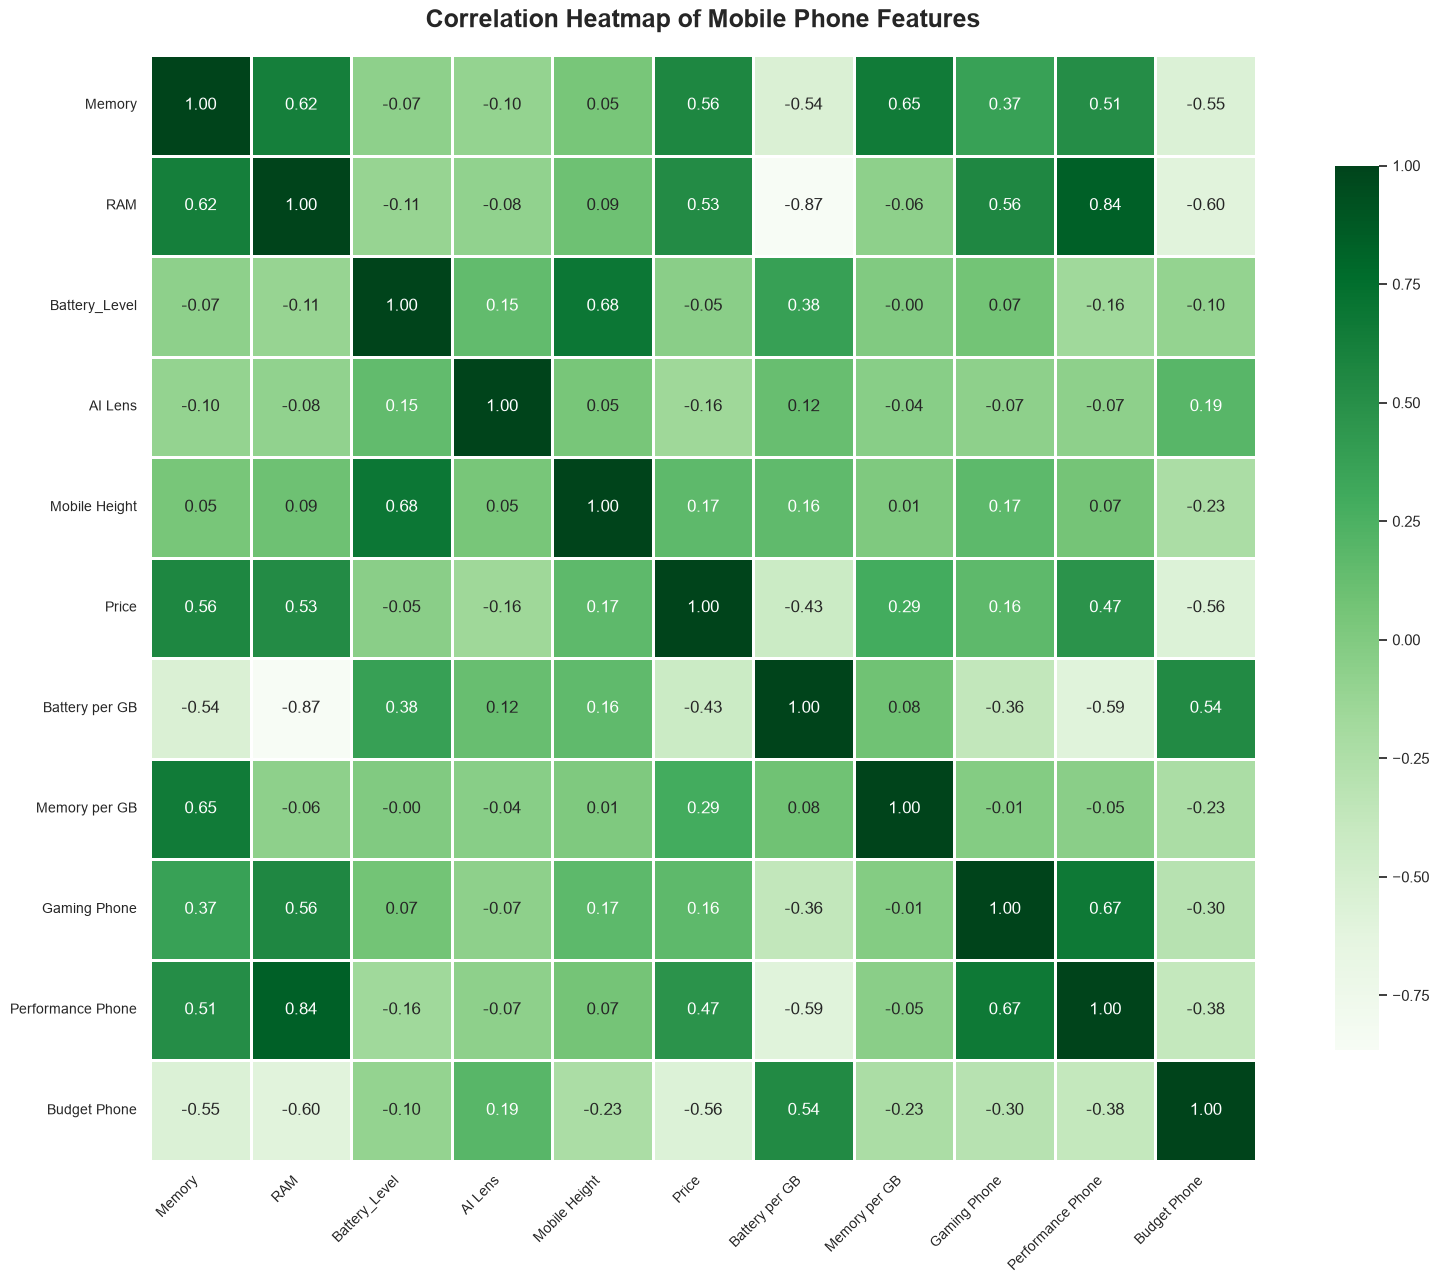

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Use feature-engineered dataframe
data = df_fe.copy() if "df_fe" in globals() else df.copy()

# Numeric features
features = [
    "Memory", "RAM", "Battery_Level",
    "Rear Camera", "Front Camera", "Total Camera MP",
    "AI Lens", "Mobile Height", "Price",
    "Battery per GB", "Memory per GB",
    "Gaming Phone", "Camera Phone",
    "Performance Phone", "Budget Phone"
]

# Keep existing columns
features = [c for c in features if c in data.columns]

# Convert to numeric
for col in features:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Correlation matrix
corr = data[features].corr()

# Remove empty columns
corr = corr.dropna(axis=0, how="all").dropna(axis=1, how="all")

# Green heatmap
plt.figure(figsize=(17, 13))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.8,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap of Mobile Phone Features",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

## 21. Feature Extraction

This stage uses statistical feature-selection methods to identify numeric variables that carry predictive information.

Two complementary methods are used:

1. **Mutual Information** — can capture nonlinear dependency.
2. **SelectKBest with mutual information** — formalizes the ranking into a selectable subset.

These are analysis tools, not automatic instructions to delete every feature that ranks low. Tree models can still benefit from interactions and categorical structure.

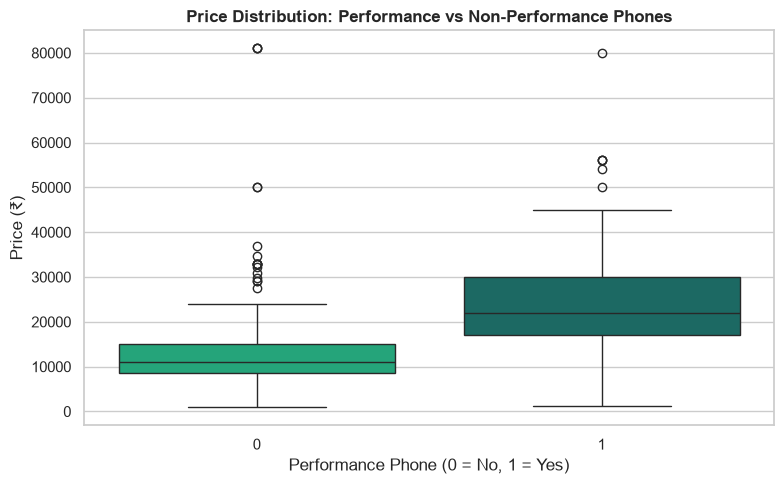

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

data = df_fe.copy() if "df_fe" in globals() else df.copy()
price = "Price" if "Price" in data.columns else "Prize"

if "Performance Phone" not in data.columns:
    data["Performance Phone"] = (pd.to_numeric(data["RAM"], errors="coerce") >= 8).astype(int)

data[price] = pd.to_numeric(data[price], errors="coerce")
plot_data = data[["Performance Phone", price]].dropna()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_data,
    x="Performance Phone",
    y=price,
    hue="Performance Phone",
    palette=["#10B981", "#0F766E"],
    legend=False
)

plt.title("Price Distribution: Performance vs Non-Performance Phones",
          fontweight="bold")
plt.xlabel("Performance Phone (0 = No, 1 = Yes)")
plt.ylabel("Price (₹)")
plt.tight_layout()
plt.show()

## 22. Feature Selection

The final ML feature set is not restricted to the top statistical features. Instead, the notebook compares the full cleaned feature set with an engineered feature set and lets cross-validation determine whether the additional information helps.

This is preferable to hand-picking features from one correlation table because feature selection itself can overfit if it is optimized against the test set.

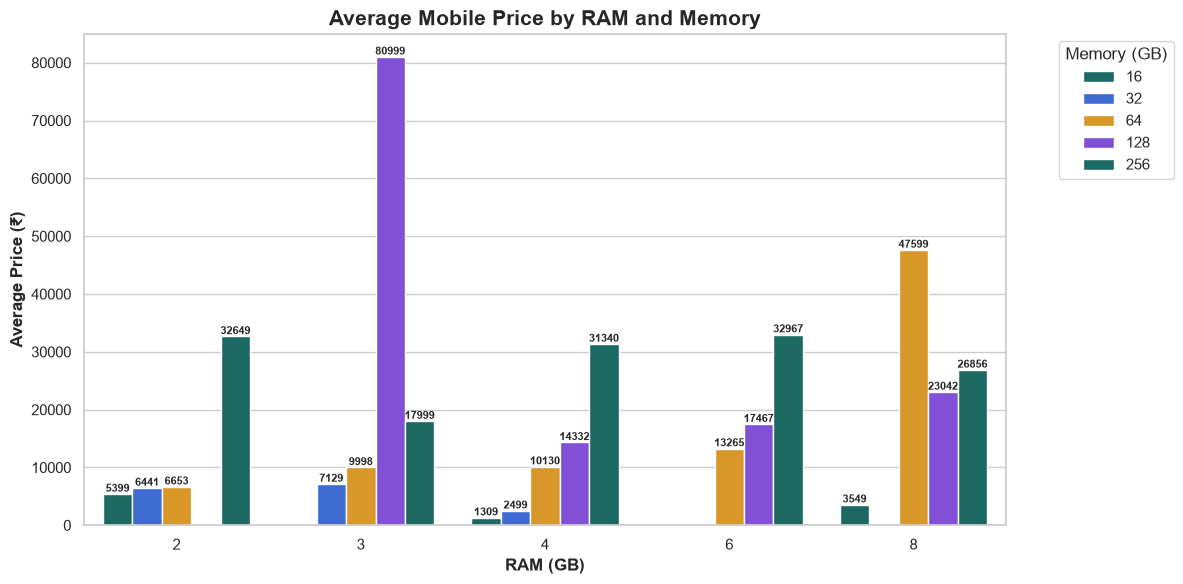

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

d = df_fe.copy() if "df_fe" in globals() else df.copy()
price = "Price" if "Price" in d.columns else "Prize"
d[["RAM","Memory",price]] = d[["RAM","Memory",price]].apply(pd.to_numeric, errors="coerce")
d = d.dropna(subset=["RAM","Memory",price])

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=d, x="RAM", y=price, hue="Memory",
    estimator="mean", errorbar=None,
    palette=['#0F766E','#2563EB','#F59E0B','#7C3AED'], ax=ax
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

ax.set_title("Average Mobile Price by RAM and Memory", fontsize=15, fontweight="bold")
ax.set_xlabel("RAM (GB)", fontweight="bold")
ax.set_ylabel("Average Price (₹)", fontweight="bold")
ax.legend(title="Memory (GB)", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()

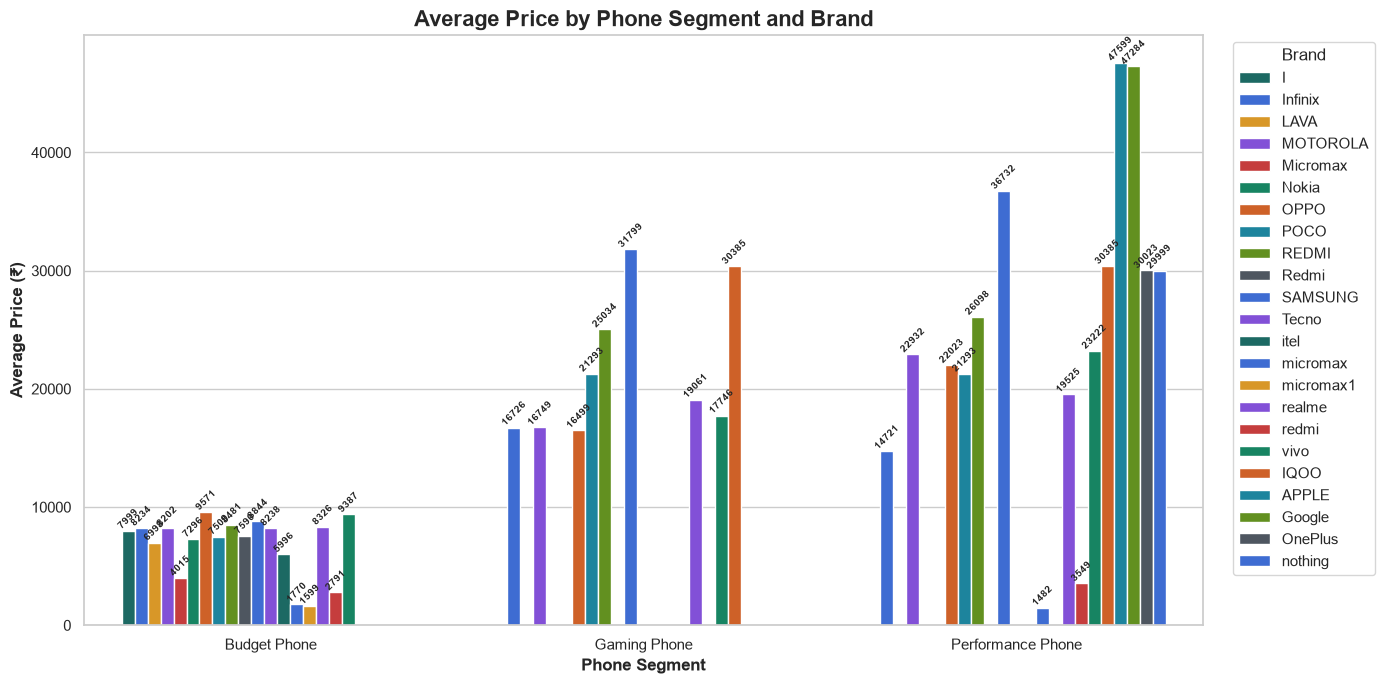

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

d = df_fe.copy() if "df_fe" in globals() else df.copy()
price = "Price" if "Price" in d.columns else "Prize"

segments = ["Gaming Phone", "Camera Phone", "Performance Phone", "Budget Phone"]

d[price] = pd.to_numeric(d[price], errors="coerce")

for c in segments:
    d[c] = pd.to_numeric(d[c], errors="coerce")

d["Brand"] = d["Brand"].astype(str)

long = d.melt(
    id_vars=["Brand", price],
    value_vars=segments,
    var_name="Phone Segment",
    value_name="Value"
)

plot_data = (
    long[long["Value"] == 1]
    .dropna(subset=[price])
    .groupby(["Phone Segment", "Brand"], as_index=False)[price]
    .mean()
)

colors = [
    "#0F766E", "#2563EB", "#F59E0B", "#7C3AED",
    "#DC2626", "#059669", "#EA580C", "#0891B2",
    "#65A30D", "#4B5563", "#2563EB", "#7C3AED"
]

fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=plot_data,
    x="Phone Segment",
    y=price,
    hue="Brand",
    palette=colors,
    errorbar=None,
    ax=ax
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{int(h)}",
            (p.get_x() + p.get_width()/2, h),
            ha="center",
            va="bottom",
            fontsize=7,
            fontweight="bold",
            rotation=45
        )

ax.set_title(
    "Average Price by Phone Segment and Brand",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Phone Segment", fontweight="bold")
ax.set_ylabel("Average Price (₹)", fontweight="bold")

ax.legend(
    title="Brand",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Conclusion

The analysis shows that mobile phone price is strongly influenced by hardware features such as RAM, memory, camera capability, and overall performance. Premium phones generally have higher camera specifications and prices compared with budget and mid-range phones.

The visualizations and correlation analysis helped identify important relationships between phone features and price. These insights can be useful for building a machine learning model to predict mobile phone prices.

### Key Findings
- Higher RAM and memory are generally associated with higher prices.
- Better camera specifications are commonly found in higher-priced phones.
- Performance-oriented phones tend to have higher average prices.
- Price segments show clear differences in hardware capabilities.
- Correlation analysis helps identify the most important numerical features for price prediction.

### Final Outcome

The dataset was successfully explored, cleaned, and transformed through feature engineering. The analysis provides a strong foundation for developing a **machine learning model for mobile phone price prediction**.